# Resolución tarea final - Predicción Stock Market

A lo largo de esta práctica he ido redefiniendo funciones y repitiendo algunas cargas o lecturas de archivos de forma intencionada. Debido a que estoy entrenando varios modelos dentro del mismo entorno y quiero asegurarme de que no exista ningún tipo de data leakage ni transferencia de información entre conjuntos o modelos. Aunque esta estructura no sea la más eficiente, lo he hecho así intencionadamente para mantener la independencia de cada experimento de modelo, garantizando que los resultados sean comparables, válidos y reproducibles.

In [32]:
# Importaciones de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from typing import List
import cloudpickle
warnings.filterwarnings("ignore")

### 1. DATASET

**Visualizo el dataset para analizar la estructura**

In [33]:
# Carga de los datos y features
DATA_VERSION = "v5.0"
df = pd.read_parquet(f"{DATA_VERSION}/train.parquet")
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

# feature_set = feature_sets["small"]
feature_set = feature_sets["medium"]
print(feature_set)

train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)
# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
train = train[train["era"].isin(train["era"].unique()[::2])]
# train = train[train["era"].isin(train["era"].unique()[::4])]
train

small 42
medium 705
all 2376
['feature_able_deprived_nona', 'feature_ablest_inflexional_egeria', 'feature_absorbable_hyperalgesic_mode', 'feature_accoutered_revolute_vexillology', 'feature_acetose_crackerjack_needlecraft', 'feature_acheulian_conserving_output', 'feature_acronychal_bilobate_stevenage', 'feature_acrylic_gallic_wine', 'feature_adminicular_shod_levant', 'feature_adorable_infernal_cartesianism', 'feature_adorable_unsuitable_cholecystectomy', 'feature_advertent_deferent_kaif', 'feature_aeneolithic_nineteenth_whipper', 'feature_afoul_drainable_cateran', 'feature_agamid_yuletide_physiology', 'feature_aired_temptable_murmansk', 'feature_alarming_forenamed_shearing', 'feature_aliunde_unhaunted_coacervate', 'feature_altern_packaged_presbyterian', 'feature_analgesic_pensionary_exterior', 'feature_analogical_obstructed_martingale', 'feature_anomic_isocyclic_absinth', 'feature_antediluvian_establishmentarian_zebra', 'feature_anthracoid_tamable_consulship', 'feature_antidepressant_ra

,era,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,1,2,3,2,3,2,2,2,...,2,0,3,2,4,3,2,1,0,0
n003bba8a98662e4,0001,0.25,3,2,4,1,0,2,3,2,...,2,0,0,2,0,0,2,0,0,0
n003bee128c2fcfc,0001,0.75,1,2,0,2,4,2,0,2,...,2,3,3,2,2,3,2,2,2,4
n0048ac83aff7194,0001,0.25,1,2,3,4,0,2,3,2,...,2,0,2,1,1,4,2,0,2,1
n0055a2401ba6480,0001,0.25,3,2,3,4,1,2,4,2,...,2,1,3,3,2,4,2,4,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,3,3,2,2,3,0,4,3,...,3,3,3,0,3,2,0,4,2,4
nffc9844c1c7a6a9,0573,0.25,0,1,2,1,3,2,2,1,...,1,0,1,1,0,3,0,2,1,2
nffd79773f4109bb,0573,0.50,3,1,1,1,3,2,2,0,...,1,0,2,1,2,4,4,0,1,2


#### 1.1 Visualización de datos

A continuación muestro distintas gráficas para entender como es la distribución de los datos y de esta manera poder hacer posteriormente un mejor pre-procesamiento y entrenamiento de los modelos.

**Figura 1: Histograma de la variable target**
- En ella muestro la distribución estadística de la variable objetivo que el modelo debe predecir.
- Podemos ver que *target* es una variable continua y centrada en 0, con valores entre -0.2 y +0.2.
- Además tiene una forma simétrica lo que nos indica que está bien normalizado y equilibrado el dataset.

**Figura 2: Distribución de las variables features**
- En esta figura muestro como se distribuyen los valores de varias features del dataset. Añadiendo valor como la mediana de cada feature y saber que cantidad de outliers presentan que son representados en los palos extremos.
- Al tener los mismos rangos las features o muy similares, podemos concluir que las columnas están bien escaladas. Esto también nos puede servir para luego eliminar columnas correlacionadas y reducir redundancia.

**Figura 3: Correlación media de features con target**
- Muestro la correlación lineal entre *target* y cada una de las features que tenemos.
- Contra mayor sean los valores absolutos nos indica que esa clase es más predictiva individualmente.
- El dataset presenta muchas features con correlaciones negativas y positivas, lo que nos indica un buen punto de diversidad.

**Figura 4: Evolución de la media por era**
- En esta gráfica podemos ver como evoluciona la media de una feature concreta a lo largo del tiempo (eras).
- Además podemos ver que ninguna presenta una linea estable como resultado, lo que indica que la distribución cambia con las eras produciendo *data drift*, que hace que el Sharpe se degrada malamente.

**Figura 5: Correlación por era entre feature y target**
- Explica como cambia la fuerza de correlación entre una feature y el target a lo largo del tiempo.
- Esto nos permite medir la consistencia de la señal predictiva.
    - Si esta correlación se mantiene del mismo signo entre eras, produce una señal estable.
    - Si cambia mucho de signo, tiende a la varianza, la feature no es fiable o es muy sensible a las condiciones cambiantes de mercado.

**Figura 6: Reduccion dimensionalidad PCA**
- Proyecta las features en dos comoponentes principales, mediante PCA, se diferencian por el color en base al valor de target.
- Al visualizarlo con colores, podemos saber que si hay un gradiente de colores visible, el target tiene una estructura respecto a las features, haciendo que el modelo pueda aprender algo real. En cambio si hay una mezcla de colores, el target es muy ruidoso y puede ser complicado sacar un modelo robusto.

**Figura 7: Distribución de correlaciones por era**
- Muestra como se distribuyen las correlaciones entre features en función del tiempo.
- Nos mide la estabilidad general del dataset.
- Al contar con unos datos balanceados en su mayoria a valores negativos, esto nos indica que puede haber posibles fugas o features inestables. Lo cual es muy negativo.

**Figura 8: Correlación entre eras**
- Nos muestra la similaridad entre eras, la cual es medida por la correlación de las medias de features entre eras.

Text(0.5, 1.0, 'Correlación entre eras (mean de features)')

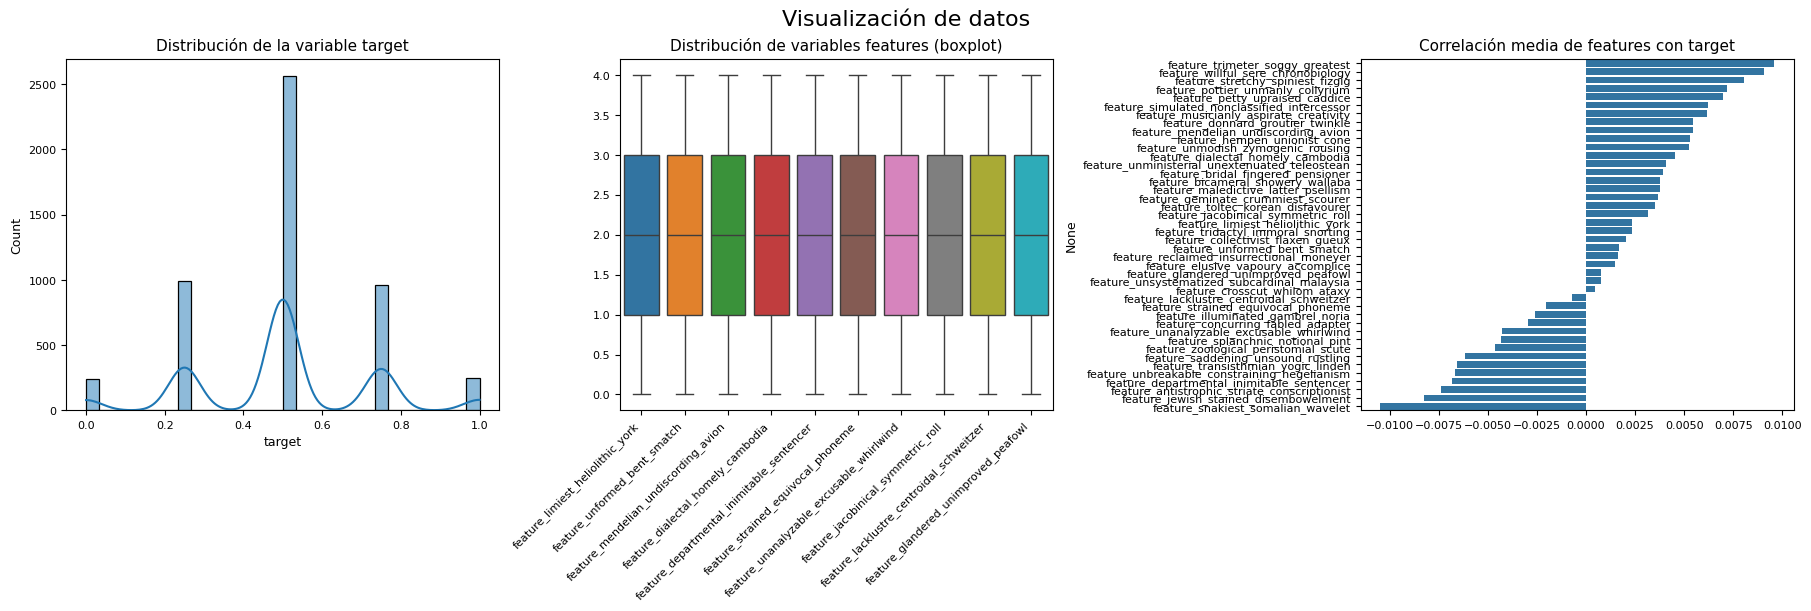

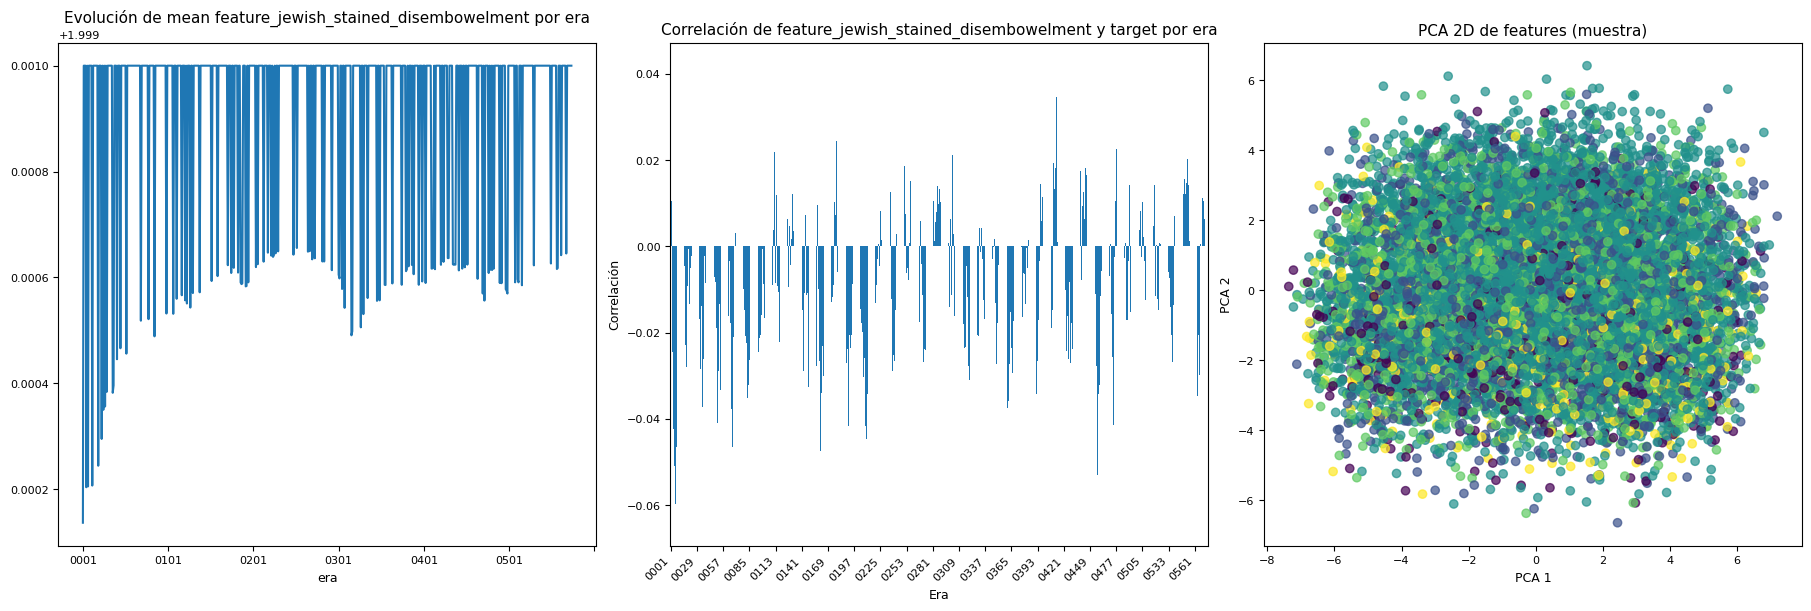

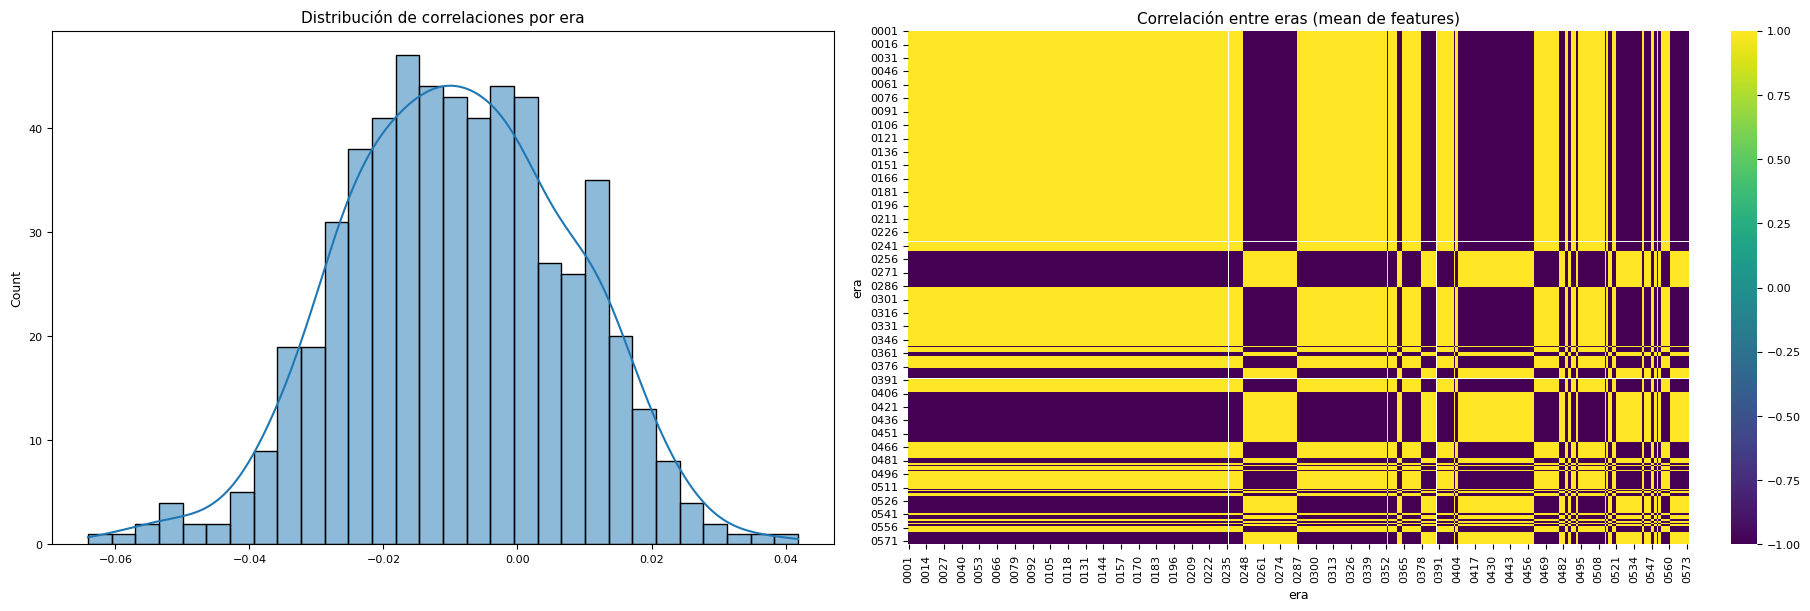

In [ ]:
# Graficas de visualización datos en 3x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
fig.suptitle("Visualización de datos", fontsize=16)
sample = train.sample(n=5000, random_state=42)

# 1. Histograma de la variable target
sns.histplot(sample["target"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribución de la variable target")

# 2. Distribución de las variables features (boxplot)
sample_features = np.random.choice(feature_set, 10, replace=False)
sns.boxplot(data=train[sample_features], ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].tick_params(axis='x', labelsize=8)
axes[1].set_title("Distribución de variables features (boxplot)")

# 3. Correlación media de features con target
feature_target_corr = train[feature_set].corrwith(train["target"]).sort_values(ascending=False)
sns.barplot(x=feature_target_corr.values, y=feature_target_corr.index, ax=axes[2])
axes[2].set_title("Correlación media de features con target")

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# 4. Evolución de la media por era
feature = np.random.choice(feature_set)
era_means = train.groupby("era")[feature].mean()
era_means.plot(ax=axes2[0], title=f"Evolución de mean {feature} por era")

# 5. Correlación por era entre feature y target
per_era_corrs = train.groupby("era").apply(lambda x: x[feature].corr(x["target"]))
ax = axes2[1]
per_era_corrs.plot(ax=ax, title=f"Correlación de {feature} y target por era", kind="bar")
show_every = max(1, len(per_era_corrs) // 20)
xticks = np.arange(0, len(per_era_corrs), show_every)
ax.set_xticks(xticks)
ax.set_xticklabels(per_era_corrs.index[::show_every], rotation=45, ha='right')
ax.set_xlabel("Era")
ax.set_ylabel("Correlación")

# 6. Reduccion dimensionalidad PCA 2D
sample = train.sample(10000, random_state=42)
X = sample[feature_set]
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)
axes2[2].scatter(pca_data[:, 0], pca_data[:, 1], c=sample["target"], cmap="viridis", alpha=0.7)
axes2[2].set_title("PCA 2D de features (muestra)")
axes2[2].set_xlabel("PCA 1")
axes2[2].set_ylabel("PCA 2")

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

# 7. Distribución de correlaciones por era (histograma)
sns.histplot(per_era_corrs, bins=30, kde=True, ax=axes3[0])
axes3[0].set_title("Distribución de correlaciones por era")

# 8. Correlación entre eras (estructura temporal global)
era_means = train.groupby("era")[feature_set].mean()
era_corr = era_means.T.corr()
sns.heatmap(era_corr, cmap="viridis", ax=axes3[1])
axes3[1].set_title("Correlación entre eras (mean de features)")

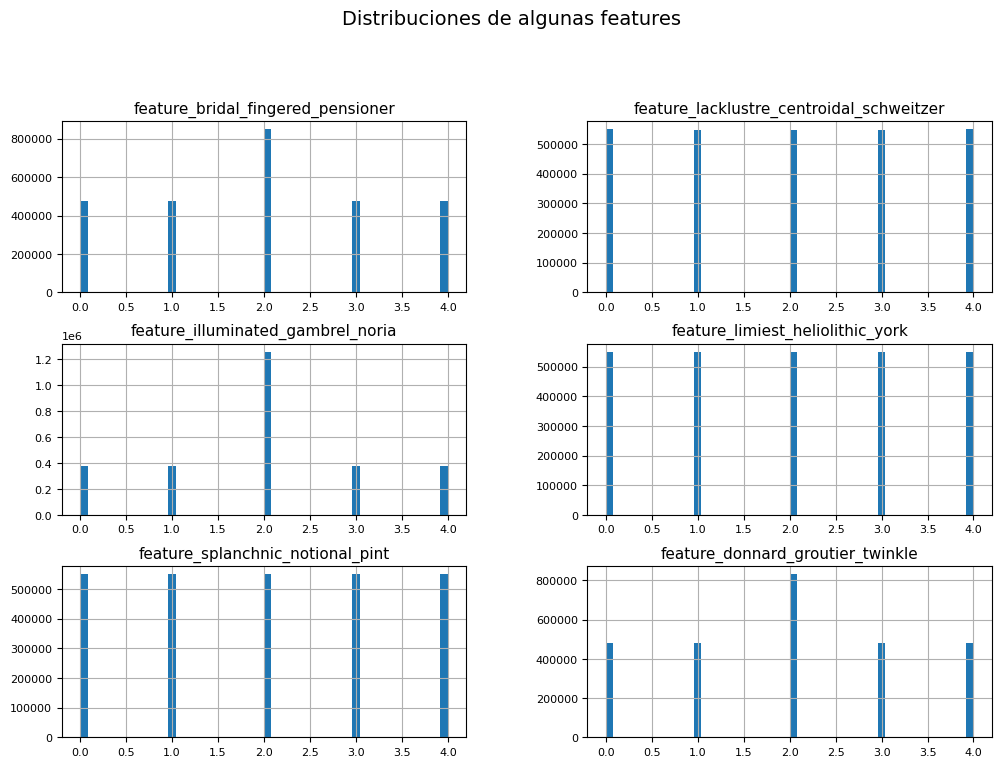

In [17]:
# Distribuciones de features
sample_features = np.random.choice(feature_set, 6, replace=False)
train[sample_features].hist(bins=50, figsize=(12,8))
plt.suptitle("Distribuciones de algunas features", y=1.02)
plt.show()

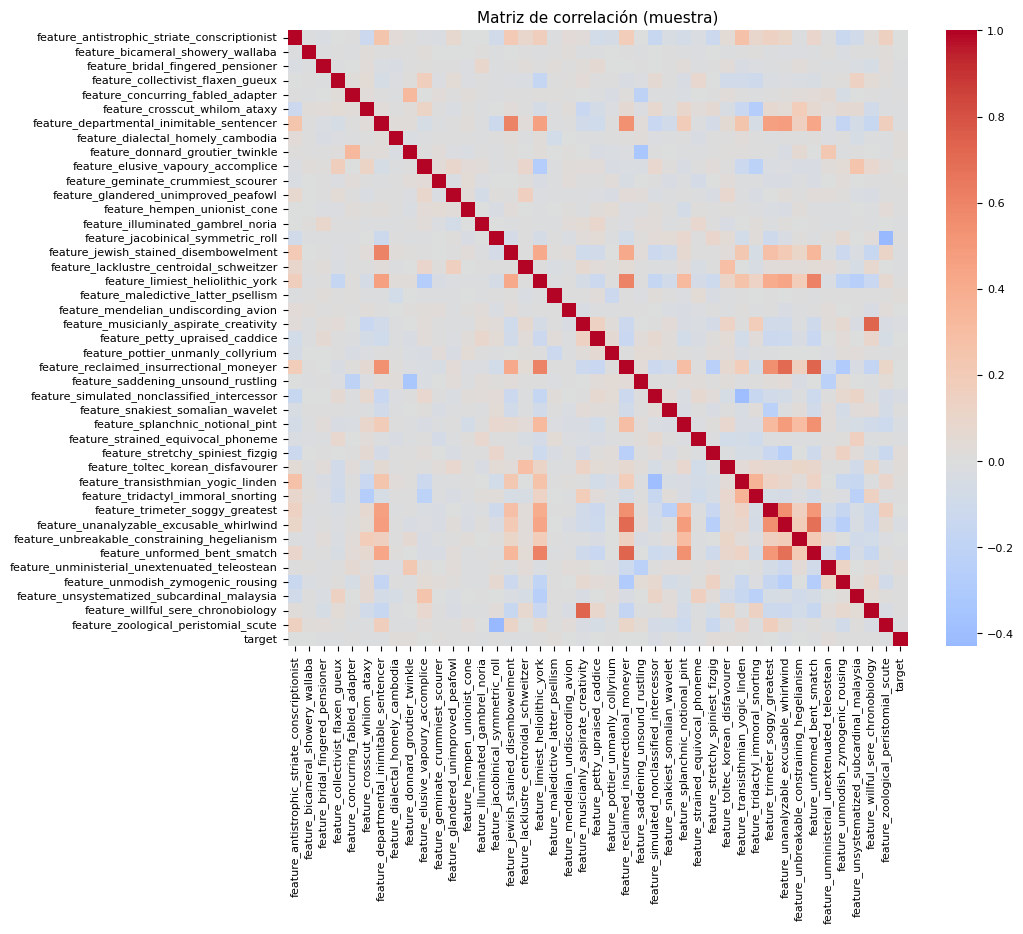

In [ ]:
# Heatmap de correlaciones features - target
corr_matrix = train[feature_set + ["target"]].sample(5000).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (muestra)")
plt.show()

#### 1.2 Pre-procesamiento - Feature Engineering

In [35]:
# Visualizar el shape del conjunto de datos
print("Shape del conjunto de datos de entrenamiento:", train.shape)

Shape del conjunto de datos de entrenamiento: (1372218, 707)


In [36]:
# Muestra aleatoria de 10000 filas para visualización del dataset
sample = train.sample(10000, random_state=42)
sample

,era,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
id,,,,,,,,,,,,,,,,,,,,,
n4aa1edefe989048,0497,0.75,0,2,1,2,2,2,4,1,...,3,4,2,3,3,3,0,3,3,2
n8c84a3ac0d6adf6,0477,0.25,1,2,1,1,1,4,4,4,...,0,4,1,0,1,3,2,2,2,4
nd05f1243038be6a,0139,0.25,0,4,4,4,2,2,2,0,...,4,3,3,1,2,0,4,1,3,2
nafe90a90f0c7e9e,0507,0.75,0,4,2,4,2,0,3,0,...,3,1,3,3,4,3,1,3,0,4
nbe4247a0b8594bb,0285,0.50,3,2,0,0,0,3,3,2,...,2,1,0,3,2,1,3,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nbff7b7f7ed83fef,0371,0.50,0,4,0,3,4,2,0,3,...,0,2,3,4,1,4,0,2,4,2
nf8ad51881948b51,0139,0.50,1,2,2,3,2,2,0,0,...,2,0,4,2,0,4,4,0,1,0
n9c35e975c9ac506,0199,0.25,4,0,3,3,2,2,3,4,...,1,1,3,1,0,2,0,2,0,1


In [37]:
# Visualizar si hay valores nulos en el conjunto de datos
train.isnull().sum()


era                                     0
target                                  0
feature_able_deprived_nona              0
feature_ablest_inflexional_egeria       0
feature_absorbable_hyperalgesic_mode    0
                                       ..
feature_zippy_trine_diffraction         0
feature_zonal_snuffly_chemism           0
feature_zygotic_middlebrow_caribbean    0
feature_zymolytic_intertidal_privet     0
feature_zymotic_windswept_cooky         0
Length: 707, dtype: int64

#### Eliminacion de características poco relevantes
He eliminado las columnas con características poco relevantes, para ello he quitado las columnas con varianza practicamente nula, quitado las features con una correlación muy baja con el target y las features con correlación y redundantes entre ellas.

Tras la eliminación de las columnas irrelevantes, pasamos de tener un dataset train compuesto por 705 columnas a un dataset más limpio compuesto por 313 features.

Para la eliminación de características, utilicé varios métodos, entre los que se encuentran eliminar aquellas categorías con una baja varianza, las que tienen poca relación con el objetivo *target* y la eliminación de las características con una alta correlación entre ellas.

El órden de ejecución es además ese, debido a que:
- Baja varianza nos permite quitar categorías muertas sin mirar el target que contiene asignado.
- Correlación con target reduce el ruido global del dataset ya sobre el conjunto de datos más limpio.
- Redundancia entre features compacta el espacio de las características y evita que haya en el dataset duplicados con valores casi idénticos.

Explicación detallada de cada implementación:
- Filtro de baja varianza:
    - Mide la varianza de cada feature.
    - Descarta columnas casi constantes (varianza ≤ 1e-5).
    - Una columna casi constante no aporta información al modelo y puede introducir ruido numérico o ralentizar el entrenamien.

- Filtro por correlación con *target*:
    - Mide la **correlación de Pearson** entre cada *feature* y *target*, en valor absoluto.
    - Mantiene solo columnas con |corr| ≥ 0.002.
    - Elimina columnas cuya relación lineal con el objetivo es extremadamente débil a nivel global → probable ruido.

- Filtro de redundancia entre features:
    - Mide la correlación entre features mediante *Pearson* y en valor absoluto.
    - Si una columna está muy correlacionada con otra (>|0.98|), se elimina una de ellas.
    - Reduce duplicación de información; menos riesgo de sobreajuste y entrenamiento más rápido.

In [38]:
# Función para eliminar características poco relevantes
train_deleted_features = train.copy()

def eliminar_features_irrelevantes(
    df: pd.DataFrame,
    target_col: str = "target",
    var_threshold: float = 1e-5,
    corr_threshold: float = 0.98,
    min_target_corr: float = 0.002
):
    feature_cols = [c for c in df.columns if c.startswith("feature_")]
    df_feat = df[feature_cols]

    print(f"Total de features iniciales: {len(feature_cols)}")

    # Eliminar baja varianza
    variances = df_feat.var(ddof=0)
    keep = variances[variances > var_threshold].index.tolist()
    df_feat = df_feat[keep]
    print(f"Tras eliminar baja varianza: {len(keep)} columnas")

    # Eliminar features con poca correlación con target
    corr_target = df_feat.corrwith(df[target_col]).abs()
    relevant_feats = corr_target[corr_target >= min_target_corr].index.tolist()
    df_feat = df_feat[relevant_feats]
    print(f"Tras eliminar baja correlación con target (< {min_target_corr}): {len(relevant_feats)} columnas")

    # Eliminar features altamente correlacionadas entre sí
    corr_matrix = df_feat.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
    final_feats = [f for f in relevant_feats if f not in to_drop]
    print(f"Tras eliminar redundantes (corr > {corr_threshold}): {len(final_feats)} columnas finales")

    df_clean = pd.concat([df[target_col], df["era"], df[final_feats]], axis=1)
    return df_clean, final_feats

train_cleaned, useful_features = eliminar_features_irrelevantes(train_deleted_features)
train_cleaned

Total de features iniciales: 705
Tras eliminar baja varianza: 705 columnas
Tras eliminar baja correlación con target (< 0.002): 313 columnas
Tras eliminar redundantes (corr > 0.98): 313 columnas finales


,target,era,feature_able_deprived_nona,feature_accoutered_revolute_vexillology,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,feature_adminicular_shod_levant,feature_advertent_deferent_kaif,feature_aeneolithic_nineteenth_whipper,feature_afoul_drainable_cateran,...,feature_vestigial_tittering_cyan,feature_victimized_distributed_pyridoxine,feature_waterproofed_damfool_alerce,feature_weeping_caucasoid_ubiety,feature_whapping_liny_prelate,feature_willyard_regionalism_eritrea,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zygotic_middlebrow_caribbean,feature_zymotic_windswept_cooky
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0.25,0001,1,2,2,2,3,0,0,2,...,1,2,1,1,3,0,3,2,1,0
n003bba8a98662e4,0.25,0001,3,1,3,2,4,2,0,0,...,0,2,0,2,3,3,0,2,0,0
n003bee128c2fcfc,0.75,0001,1,2,0,2,0,1,3,3,...,1,2,1,4,0,2,3,2,2,4
n0048ac83aff7194,0.25,0001,1,4,3,2,3,4,4,0,...,0,2,0,2,0,3,2,1,0,1
n0055a2401ba6480,0.25,0001,3,4,4,2,3,4,4,0,...,4,2,3,2,2,1,3,3,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0.00,0573,3,2,4,3,1,0,4,4,...,1,1,2,4,3,0,3,0,4,4
nffc9844c1c7a6a9,0.25,0573,0,1,2,1,4,2,2,0,...,0,4,3,0,1,1,1,1,2,2
nffd79773f4109bb,0.50,0573,3,1,2,0,1,3,0,2,...,1,2,3,0,2,0,2,1,0,2


#### Aplicar PCA a los datos iniciales
Anteriormente mediante el .shape sobre el dataframe train pudimos ver que contenía 705 columnas numéricas con valores para el entrenamiento. Tras aplicar PCA sobre estos datos iniciales, nos quedamos con un total de 314 categorías para el entrenamiento del modelo que explican el 95% de la varianza del modelo y de los datos.

Con esto hemos conseguido reducir la dimensionalidad del dataset inicial en aprox. un 55% manteniendo una explicación de la varianza de los datos de un 95%.

In [39]:
# Aplicar PCA y reducir dimensionalidad
train_pca = train.copy()
train_pca_features = train_pca[feature_set]
pca = PCA(n_components=0.95, random_state=42)
pca.fit(train_pca_features)
train_pca_features = pca.transform(train_pca_features)
train_pca = pd.DataFrame(
    train_pca_features,
    columns=[f"PCA_{i+1}" for i in range(train_pca_features.shape[1])]
)
train_pca["era"] = train["era"].values
train_pca["target"] = train["target"].values
train_pca

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,...,PCA_305,PCA_306,PCA_307,PCA_308,PCA_309,PCA_310,PCA_311,PCA_312,era,target
0,-9.290117,3.056643,-3.823523,3.484117,3.935880,7.473832,3.998244,-2.948918,0.388871,-2.898228,...,-1.135649,-1.072093,-0.500140,1.375563,0.010858,0.320653,0.608060,-0.321376,0001,0.25
1,-8.686809,-8.621952,-1.411709,6.584533,0.181237,1.359644,-0.334791,-3.306686,1.456110,3.045215,...,1.113605,0.603701,-1.283841,0.021165,0.132795,-1.184981,-2.090590,-0.641148,0001,0.25
2,-0.251604,10.492749,-6.807860,-1.685414,-1.210832,-0.734365,1.677446,1.544030,0.279649,-0.665238,...,-1.015012,-0.004504,0.701867,-0.123197,0.121880,-0.096245,-0.542171,0.012696,0001,0.75
3,1.847861,-13.852454,-0.884755,-6.761469,0.568994,6.421118,2.239511,6.143086,-2.099480,-0.060574,...,-0.468701,0.671039,-0.086783,-0.035785,-0.762981,0.524597,0.356677,-0.074782,0001,0.25
4,-4.013328,-5.984699,-1.309101,-1.844160,-5.234131,0.178697,-0.108757,5.369625,-8.189385,4.745274,...,0.709381,0.046554,0.242272,0.283779,-0.456769,0.334680,0.148401,0.474432,0001,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1372213,8.484558,14.526177,0.481577,-3.676821,-3.217887,2.065584,4.650450,8.166220,-1.274592,-1.722344,...,-0.783488,-0.050201,0.239459,-0.810956,-0.201304,-1.152554,-0.826845,0.431140,0573,0.00
1372214,-14.721238,-1.389619,-4.321689,1.882402,-1.054108,3.513393,2.158004,3.345719,-6.363435,-4.044573,...,0.644012,1.387651,-0.506118,0.619804,0.020270,0.287136,0.463804,0.282355,0573,0.25
1372215,-13.326073,6.426779,1.620633,0.422772,0.592293,-2.315366,-0.145951,-6.100227,3.895965,-2.401727,...,0.195487,0.293736,-0.497247,0.669097,0.837381,0.410104,-0.278139,-0.623770,0573,0.50
1372216,-6.311884,0.731505,4.435430,4.591737,-1.180029,-7.565149,3.816044,-8.343094,-7.870404,-7.898421,...,0.500331,0.597894,-0.297197,0.940974,-0.592647,-1.176453,0.202672,-0.587191,0573,0.25


El dataset inicial de *train* contiene las siguientes columnas:
- id: cuyo valor es un string y actua como identificador único.
- era: cuyo valor es un string y nos indica el periodo temporal en semanas.
- target: cuyo valor es un float y es la variable a predecir.
- feature_: cuyo valor es un int comprendido entre 0 y 4.

Las columnas feature_ ya vienen con datos ofuscados y normalizados. Mantienen un rango entre los valores 0-4, con una media en aprox. 2, std de 1 y distribuciones balanceadas, ya que no se aprecia la existencia de outliers fuertes en los datos.

Esto indica que los datos que traemos de *Numerai* ya vienen con una normalización por era con el fin de eliminar el drift temporal; además presentan una estandarización global por rangos 0-4. Por lo que aplicar un escalado de los datos adicional como *StandardScaler* no mejoraría nada y puede que hasta rompiese la calibración original de los datos. Las únicas formas de pre-procesamiento que tiene sentido implementar para comparar el rendimiento de los modelos con distintas técnicas son PCA y la reducción de ruido mediante la eliminación de features; ambos procesos ya los he hecho anteriormente y se implementan acontinuación en el modelo inicial para comparar los resultados.

In [40]:
# Verificación de la normalización de las features en el dataset original
feature_cols = [c for c in train.columns if c.startswith("feature_")]
train[feature_cols].describe().T[['mean', 'std', 'min', 'max']].head(10)

,mean,std,min,max
feature_able_deprived_nona,1.999908,1.414358,0.0,4.0
feature_ablest_inflexional_egeria,1.999924,1.373232,0.0,4.0
feature_absorbable_hyperalgesic_mode,1.999908,1.414358,0.0,4.0
feature_accoutered_revolute_vexillology,1.999908,1.414358,0.0,4.0
feature_acetose_crackerjack_needlecraft,1.999908,1.414358,0.0,4.0
feature_acheulian_conserving_output,1.999948,1.164319,0.0,4.0
feature_acronychal_bilobate_stevenage,1.999908,1.414358,0.0,4.0
feature_acrylic_gallic_wine,1.999929,1.313749,0.0,4.0
feature_adminicular_shod_levant,1.999908,1.414358,0.0,4.0
feature_adorable_infernal_cartesianism,1.999908,1.414358,0.0,4.0


### 2. MODELING

#### Explicación de Overfitting y como evitarlo

El overfitting sucede cuando un modelo aprende demasiado bien los detalles y patrones específicos de los datos de entrenamiento pero no es capaz de generalizar bien en datos nuevos. Generando un error mínimo en train pero alto en validación/test.

El overfitting se puede evitar de las siguiente maneras:
- Regularización: Se pueden introducir penalizaciones que frenan la complegidad (L1, L2).
- Aumentando los datos de entrenamiento.
- Mediante validación cruzada.
- En modelos como los árboles de decisión, limitando la profundidad (max_depth).

División de los conjuntos de datos en *Train* y *Test*

In [41]:
# Dividir el dataset general
train_set, test_set = train_test_split(train, test_size=0.2, random_state=42)

# Dividir el dataset de eliminacion de features
train_set_eliminated, test_set_eliminated = train_test_split(train_cleaned, test_size=0.2, random_state=42)

# Dividir el dataset de PCA
train_set_pca, test_set_pca = train_test_split(train_pca, test_size=0.2, random_state=42)

In [43]:
# Almacenar los datos para conclusiones y comparativas finales
results_summary = {}

#### 2.1 Entrenamiento y evalución del modelo inicial propuesto


=== TEST METRICS (por eras) ===
                     0
mean          0.098513
std           0.039795
sharpe        2.475497
max_drawdown  0.018728

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.028398
std           0.022058
sharpe        1.287443
max_drawdown  0.043592


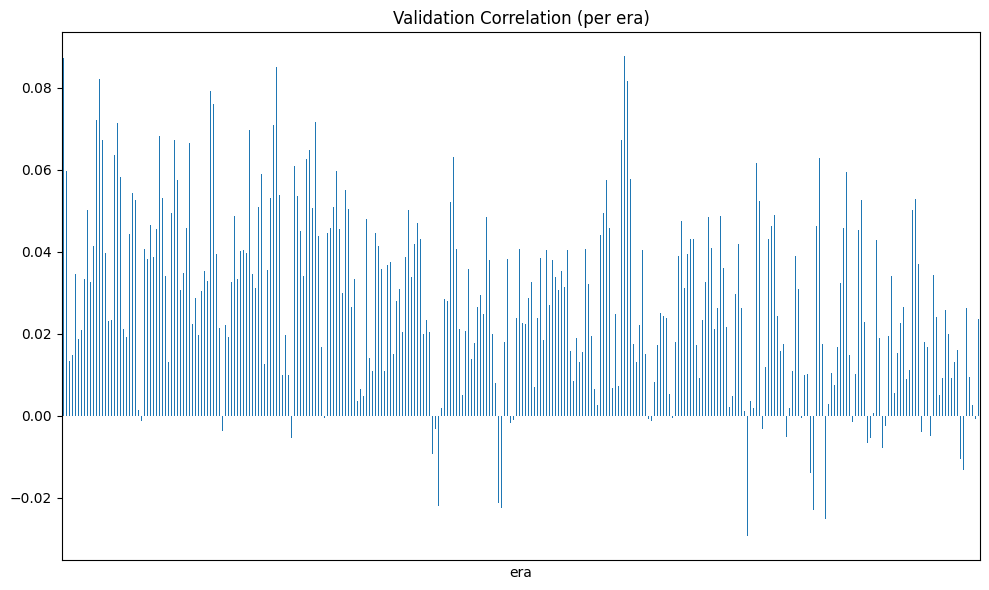

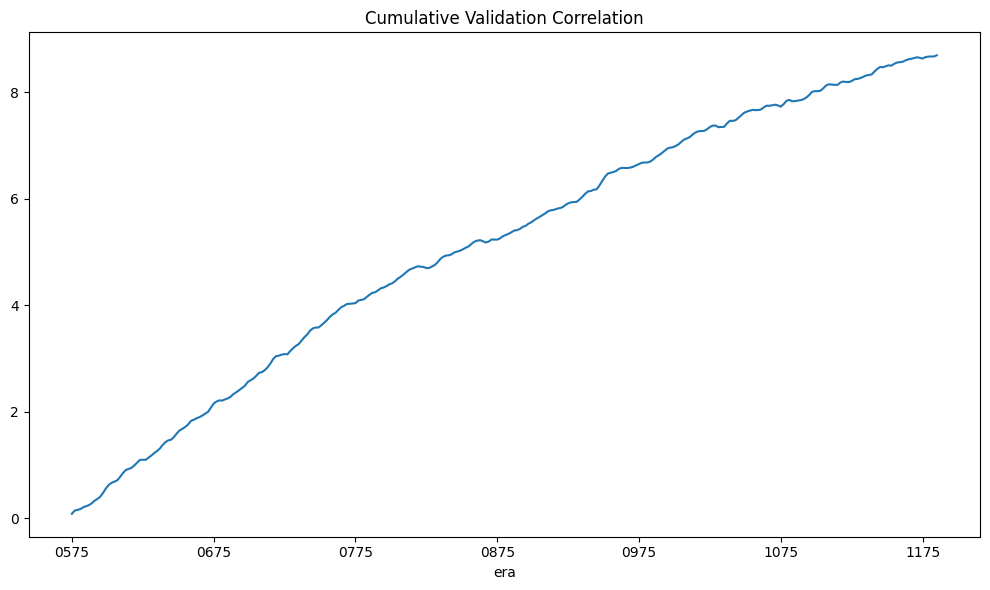


Preview VALID predictions:
                   era  prediction  target
id                                        
n000101811a8a843  0575    0.495711    0.75
n001e1318d5072ac  0575    0.514851    0.00
n002a9c5ab785cbb  0575    0.494762    0.50
n002ccf6d0e8c5ad  0575    0.518976    0.00
n0041544c345c91d  0575    0.509434    0.50


In [44]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]


# Preparación y entrenamiento del modelo LightGBM Inicial propuesto en la tarea
X = train_set[feature_set]
y = train_set["target"]
X_test = test_set[feature_set]
y_test = test_set["target"]

model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,#colsample_bytree=0.3,
  verbose=-1
)
model.fit(X, y)

# Predicciones y métricas en TEST set
test = test_set.copy()
test["prediction"] = model.predict(X_test)
per_era_corr_test = test.groupby("era").apply(lambda df: practica_corr(df["prediction"], df["target"]))
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)
test_stats = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}

# Predicciones y métricas en Validation set
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# (Opcional) reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::2])].copy()
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo: 4 eras después de la última era de train_set
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
# eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

validation["prediction"] = model.predict(validation[feature_set])

per_era_corr_val_general = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val_general.mean()
corr_std_val = per_era_corr_val_general.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val_general.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)
validation_stats = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Gráficas VALID
plt.figure(figsize=(10, 6))
per_era_corr_val_general.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val_general.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Preview
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "target"]].head())

# Guardar resultados para comparativas finales
results_summary["lgb_test_inicial"] = test_stats
results_summary["lgb_validation_inicial"] = validation_stats

#### 2.2 Entrenamiento y análisis del modelo con eliminación de características


=== TEST METRICS (por eras) ===
                     0
mean          0.084532
std           0.038396
sharpe        2.201548
max_drawdown  0.015273

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.024418
std           0.021447
sharpe        1.138533
max_drawdown  0.055783


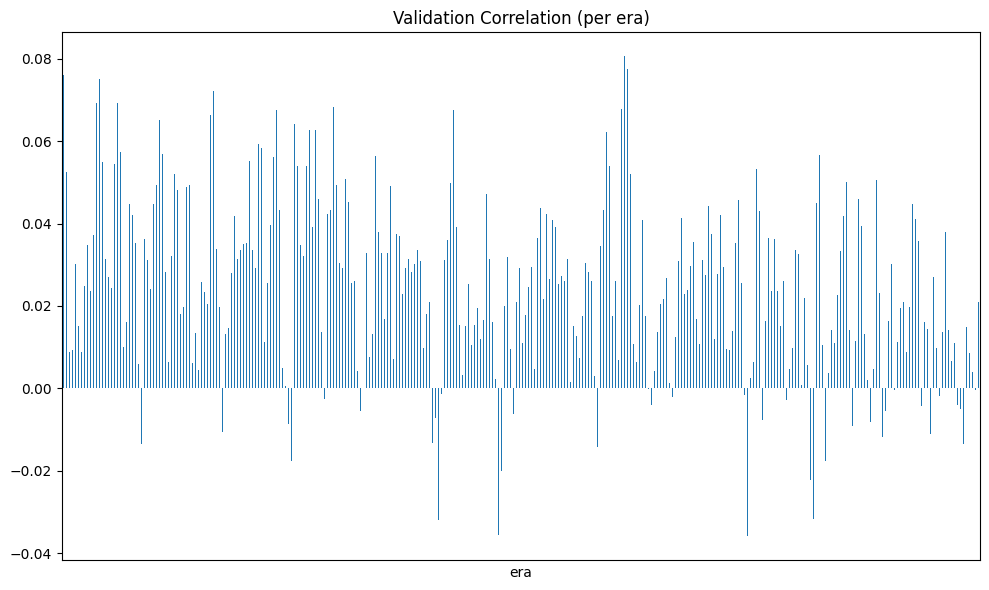

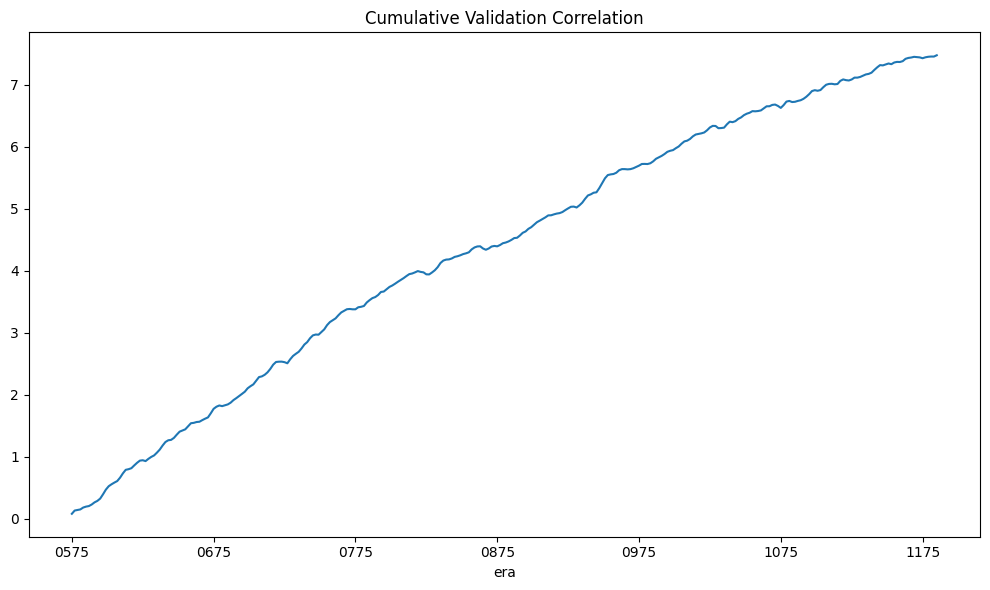


Preview VALID predictions:
                   era  prediction  target
id                                        
n000101811a8a843  0575    0.498615    0.75
n001e1318d5072ac  0575    0.508551    0.00
n002a9c5ab785cbb  0575    0.491475    0.50
n002ccf6d0e8c5ad  0575    0.525158    0.00
n0041544c345c91d  0575    0.509562    0.50


In [45]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Preparación y entrenamiento
X = train_set_eliminated[useful_features]
y = train_set_eliminated["target"]
X_test = test_set_eliminated[useful_features]
y_test = test_set_eliminated["target"]

model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,#colsample_bytree=0.3,
  verbose=-1
)
model.fit(X, y)

# Predicciones y métricas en TEST set
test = test_set_eliminated.copy()
test["prediction"] = model.predict(X_test)

per_era_corr_test = test.groupby("era").apply(lambda df: practica_corr(df["prediction"], df["target"]))
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)
test_stats = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}

# Carga y preparación VALID
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + useful_features
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::2])].copy()
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo: 4 eras después de la última era de train_set
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
# eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

# Predicción y métricas VALID
validation["prediction"] = model.predict(validation[useful_features])

per_era_corr_val_deleted_features = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val_deleted_features.mean()
corr_std_val = per_era_corr_val_deleted_features.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val_deleted_features.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)
validation_stats = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Gráficas VALID
plt.figure(figsize=(10, 6))
per_era_corr_val_deleted_features.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val_deleted_features.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Preview VALID predictions
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "target"]].head())

# Guardar resultados para comparativas finales
results_summary["lgb_test_eliminated_features"] = test_stats
results_summary["lgb_validation_eliminated_features"] = validation_stats


#### 2.3 Entrenamiento y análisis del modelo con PCA


=== TEST METRICS (por eras) ===
                     0
mean          0.077267
std           0.037091
sharpe        2.083173
max_drawdown  0.033201

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.016590
std           0.019656
sharpe        0.843982
max_drawdown  0.070391


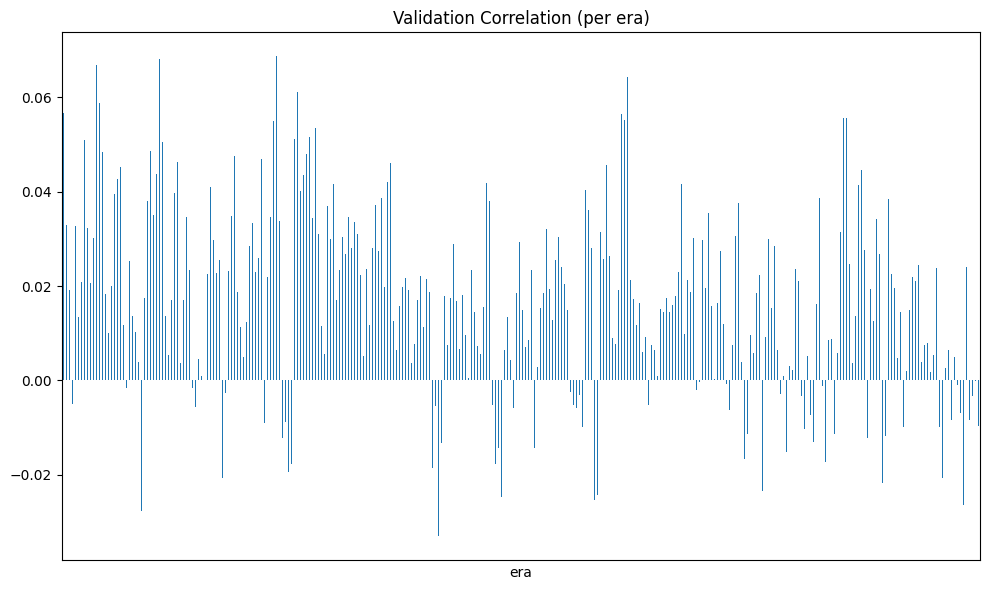

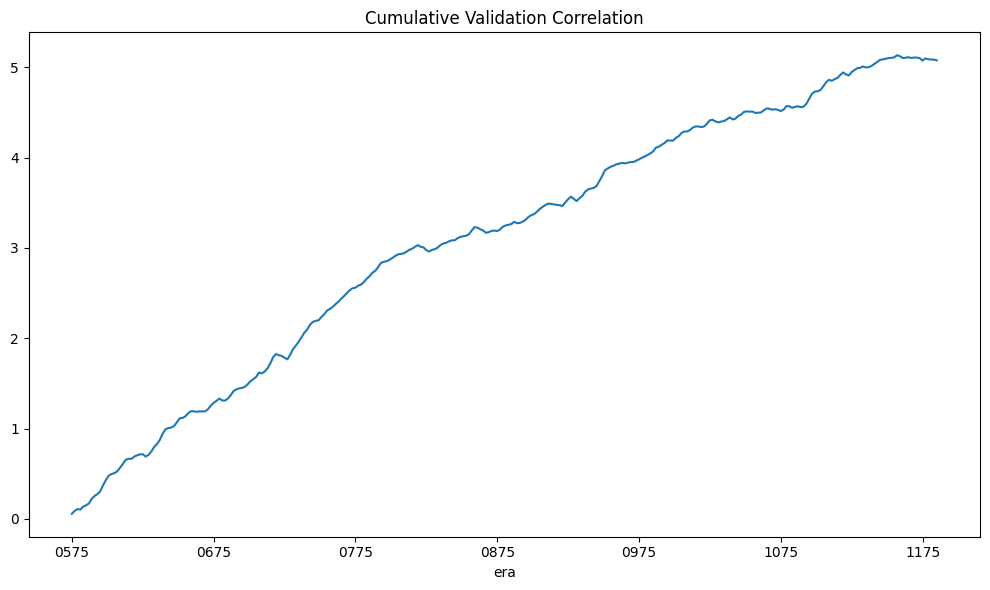


Preview VALID predictions:
                   era  prediction  target
id                                        
n000101811a8a843  0575    0.495728    0.75
n001e1318d5072ac  0575    0.498577    0.00
n002a9c5ab785cbb  0575    0.495931    0.50
n002ccf6d0e8c5ad  0575    0.509531    0.00
n0041544c345c91d  0575    0.502031    0.50


In [46]:
features_pca = [c for c in train_set_pca.columns if c.startswith("PCA_")]

def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Preparación y entrenamiento
X = train_set_pca[features_pca]
y = train_set_pca["target"]
X_test = test_set_pca[features_pca]
y_test = test_set_pca["target"]

model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,#colsample_bytree=0.3,
  verbose=-1
)
model.fit(X, y)

# Predicciones y métricas en TEST set
test_eval = test_set_pca.copy()
test_eval["prediction"] = model.predict(X_test)

per_era_corr_test = test_eval.groupby("era").apply(lambda df: practica_corr(df["prediction"], df["target"]))
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)
test_stats = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}


# Carga y preparación VALID
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# acelerar usando 1 de cada 4 eras
validation = validation[validation["era"].isin(validation["era"].unique()[::2])].copy()
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo: usa el last_train_era del SPLIT
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
# eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

# Transformación PCA en VALID
X_val_orig = validation[feature_set].values
val_pca = pca.transform(X_val_orig)  # <- el mismo objeto 'pca'
pca_df_val = pd.DataFrame(val_pca, columns=features_pca, index=validation.index)

validation_pca = pd.concat([validation[["era", "target"]], pca_df_val], axis=1)
validation_pca["prediction"] = model.predict(validation_pca[features_pca])

# Métricas VALID
per_era_corr_val_pca = validation_pca.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val_pca.mean()
corr_std_val = per_era_corr_val_pca.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val_pca.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)
validation_stats = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Gráficas VALID
plt.figure(figsize=(10, 6))
per_era_corr_val_pca.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val_pca.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Preview VALID predictions
print("\nPreview VALID predictions:")
print(validation_pca[["era", "prediction", "target"]].head())

# Guardar resultados para comparativas finales
results_summary["lgb_test_pca"] = test_stats
results_summary["lgb_validation_pca"] = validation_stats


#### 2.4 Conclusiones modelo inicial propuesto

*Modelo Inicial propuesto con todas las features*

El modelo base ofrece muy buena señal en test (Sharpe 2.48) y una señal razonable en validación (Sharpe 1.29). El drawdown en test es bajo (0.0187), y en validación es moderado (0.0436). Tomo este setup como benchmark: buena fuerza de señal y volatilidad contenida.

*Modelo Inicial propuesto con eliminación de features*

En test, al eliminar features reduzco ligeramente la varianza (std disminuye) y consigo menos drawdown (0.0153 vs 0.0187). Sin embargo, pierdo fuerza de señal (mean cae de 0.0985 a 0.0845) y eso empeora el Sharpe (2.48 → 2.20). Esto puede deberse a que el filtrado quitó algo de señal útil junto con ruido.

En validación, el patrón es más claro: menos señal (mean y Sharpe bajan) y, además, peor drawdown (sube a 0.0558). Aquí no obtengo la mejora de estabilidad que se veía en test.

La eliminación de características sí reduce ruido en test (std y drawdown bajan), pero reduce demasiado la señal y no generaliza la mejora a validación haciendo que el drawdown empeore. Probablemente el umbral de filtrado que utilicé fue demasiado agresivo y se pueden llegar a eliminar predictores realmente útiles.

*Modelo Inicial propuesto con PCA*

En test, el PCA suaviza (std baja), pero aplana demasiado la señal (mean cae con fuerza) y el Sharpe baja (2.08). Lo más relevante es que el drawdown empeora (0.0332 vs 0.0187), señal de que la reducción de dimensionalidad no preservó adecuadamente las direcciones alineadas con el target.

En validación, el efecto es más fuerte: cae la señal (mean 0.0166), Sharpe baja a 0.84 y el drawdown empeora (0.0704).

Abajo podemos ver los resultados de rendimiento comparando el modelo inicial propuesto en la tarea con todas las features, con eliminación de características y con PCA.

In [48]:
# Mostrar resumen de resultados finales
results_summary_df = pd.DataFrame(results_summary).T
results_summary_df

,mean,std,sharpe,max_drawdown
lgb_test_inicial,0.098513,0.039795,2.475497,0.018728
lgb_validation_inicial,0.028398,0.022058,1.287443,0.043592
lgb_test_eliminated_features,0.084532,0.038396,2.201548,0.015273
lgb_validation_eliminated_features,0.024418,0.021447,1.138533,0.055783
lgb_test_pca,0.077267,0.037091,2.083173,0.033201
lgb_validation_pca,0.016590,0.019656,0.843982,0.070391


### 3. Validation

#### 3.1 Explicación evaluación de modelos

Los modelos se entrenan para predecir un valor numérico continuo, correspondiente a *target*, que representa la rentabilidad futura esperada de un activo en una era determinada.
- La predicción del modelo también es continua, un valor numérico y no categórico.
- El objetivo es que las predicciones estén linealmente correlacionadas con los valores reales de nuestra columna *target* para cada una de las eras.

Cada modelo lo evaluo por bloques temporales, corresponde con las eras, calculando la correlación en cada era y resumiendo su comportamiento con cálculos como *mean, std, Sharpe ratio y máx. drawdown*. De este modo puedo medir la consistencia temporal y estabilidad fuera de muestra, parte fundamental y crítica en tareas financieras.

**Métrica Correlación de Pearson por era**

La métrica utilizada para la evaluación de los modelos fue la correlación de pearson. Al tener un problema de regresión y no de clasificación, queremos que las predicciones sean proporcionales a los valores reales (si el *target* sube, la predicción debería de subir).

La correlación de pearson, nos permite:
- Evaluar la alineación lineal, no magnitud exacta.
- Es totalmente invariante a la escala y desplazamiento de los datos.
- Refleja correctamente si el modelo captura la dirección del movimiento en el activo subyacente, que es lo importante para estrategias de inversión.

La correlación de pearson (*p*) mide cuanto se parecen las variaciones entre dos variables numéricas:
$$
\rho = \frac{\mathrm{cov}(y_{\text{pred}},\, y_{\text{true}})}{\sigma_{y_{\text{pred}}}\,\sigma_{y_{\text{true}}}}
$$

Solo puede tomar varoles entre -1 y +1:
- +1 → correlación perfecta (movimientos iguales).
- 0 → sin relación.
- −1 → relación inversa.

Por eso es la utilizada en este ejemplo de predicción de precios de mercado para un activo subyacente, ya que nos permite saber las variaciones enre nuestra predicción y el valor real de *target*; teniendo en cuenta que estas variaciones son respecto a datos anteriores ya establecidos en ambos casos idénticos.

**Porqué no F1 score**

F1 score no es una métrica de evaluación de modelo apta para este tipo de trabajos ya que es una métrica de clasificación binaria o multiclase, pero no de regresión. Al final el F1 score mide el equilibrio entre la precisión (precision) y la exhaustividad (recall); se utiliza cuando hay clases discretas.

$$
F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

En este caso no es buena práctica utilizar una métrica de evaluación de rendimiento como F1 score debido a:
- No hay clases discretas, tenemos valores continuos de rentabilidad.
- No nos interesa un acierto exacto (0 / 1) sino una tendencia global de aproximación al *target* verdadero.
- Si redujeramos nuestra columna *target* a simplemente sube o baja, para poder utilizar el F1 score como métrica de evaluación, perderíamos mucha información relevante del modelo para la predicción sobre nuevos datos y sería arbitraria.

#### 3.2 Cálculo y explicación métricas evaluación modelos

In [49]:
results_summary_df

,mean,std,sharpe,max_drawdown
lgb_test_inicial,0.098513,0.039795,2.475497,0.018728
lgb_validation_inicial,0.028398,0.022058,1.287443,0.043592
lgb_test_eliminated_features,0.084532,0.038396,2.201548,0.015273
lgb_validation_eliminated_features,0.024418,0.021447,1.138533,0.055783
lgb_test_pca,0.077267,0.037091,2.083173,0.033201
lgb_validation_pca,0.016590,0.019656,0.843982,0.070391


Al evaluar los tres modelos que entrené (modelo propuesto completo, modelo propuesto aplicando eliminación de características y modelo propuesto aplicando reducción de dimensionalidad mediante PCA) observé diferencias claras tanto en rendimiento como en estabilidad.

En general, todos los modelos lograron una correlación positiva con el target, lo que significa que las predicciones siguen la misma dirección que los valores reales. Sin embargo, el rendimiento en *validation* es siempre inferior al de test, lo cual indica la presencia de un ligero overfitting: el modelo aprende patrones específicos del periodo de entrenamiento que no se repiten con exactitud fuera de muestra.
Aun así, los valores de correlación y Sharpe en *validation* se mantienen positivos, lo que demuestra que el modelo sí captura una señal real.

Entre los tres enfoques, el modelo con eliminación de características resultó ser el más equilibrado, ya que mantiene una buena capacidad predictiva con una menor variabilidad y drawdown. El modelo completo obtiene la mayor correlación media, pero también muestra un poco más de inestabilidad, mientras que el modelo PCA ofrece predicciones más estables pero con una pérdida clara de señal en las predicciones, haciendo que su ratio sharpe baje.

Acontinuación veremos el entrenamiento y evaluación con otros modelos, comparándolos y explicando las mejoras que traen.

#### 3.3 Gráficas CORR y explicación 

En este análisis comparo los tres enfoques distintos para entrenar un modelo LightGBM (LGB) inicial propuesto en la tarea, evaluando cómo cambia el rendimiento en test y validación en función del tratamiento aplicado a las características (features). Las gráficas muestran la correlación de validación por era (izquierda) y su correlación acumulada (derecha), lo cual permite observar tanto la estabilidad del modelo en diferentes periodos como su desempeño global a lo largo del tiempo.

**1. LGB con todos los datos de entrenamiento**

En la primera fila se muestran los resultados del modelo LGB entrenado con todas las características disponibles, sin aplicar ningún tipo de filtrado ni reducción a las *features*.

En la gráfica izquierda (“Validation Correlation per era”) se aprecia una alta variabilidad entre eras, con picos positivos notables pero también con algunas caídas negativas. Esto me indica que el modelo tiene cierta capacidad predictiva, pero también sufre de inestabilidad temporal.

En la gráfica derecha (“Cumulative Validation Correlation”) se observa una tendencia positiva constante, lo que demuestra que el modelo, pese a la volatilidad, mantiene una señal útil en el largo plazo. El valor acumulado alcanza aproximadamente algo superior a 2.5, lo cual sugiere un rendimiento sólido.

**2. LGB con eliminación de características irrelevantes**

En la segunda fila aparecen los resultados del modelo tras aplicar un proceso de filtrado de features (por baja varianza, alta correlación entre sí o baja correlación con el target).

En la gráfica izquierda se nota una reducción leve de la amplitud de las fluctuaciones respecto al modelo anterior. Aunque aún hay eras negativas, la correlación es algo más estable y con menos valores extremos.

En la gráfica derecha, la curva acumulada muestra una tendencia positiva más regular y con una pendiente similar a la del modelo original, alcanzando un valor final cercano a 2.3. Esto me indica que el modelo mantiene una señal fuerte, pero ahora con mayor robustez y menor ruido en los resultados.

**3. LGB con reducción de dimensionalidad (PCA)**

En la tercera fila se presentan los resultados tras aplicar un análisis de componentes principales (PCA) antes del entrenamiento.

En la gráfica izquierda se observa una dispersión menor en los valores de correlación por era: las oscilaciones son más suaves y la mayoría de los puntos se mantienen alrededor de cero con ligeras desviaciones positivas. Esto sugiere que el PCA ha suavizado el comportamiento del modelo, capturando las direcciones principales de variabilidad sin sobreajustar a eras.

En la gráfica derecha, la correlación acumulada crece de manera más gradual y estable, alcanzando un valor final cercano a 1.8. Aunque la señal es más débil que en los casos anteriores, la curva es más lineal y menos volátil.

**Conclusión**

Comparando los tres enfoques:
- El modelo con todas las features obtiene la mayor correlación acumulada, pero es el más inestable entre eras.
- El modelo con eliminación de características mantiene un rendimiento similar pero con mejor equilibrio entre señal y estabilidad.
- El modelo con PCA muestra la menor correlación acumulada, aunque con la mayor suavidad temporal.

<Axes: title={'center': 'Cumulative Validation Correlation'}, xlabel='era'>

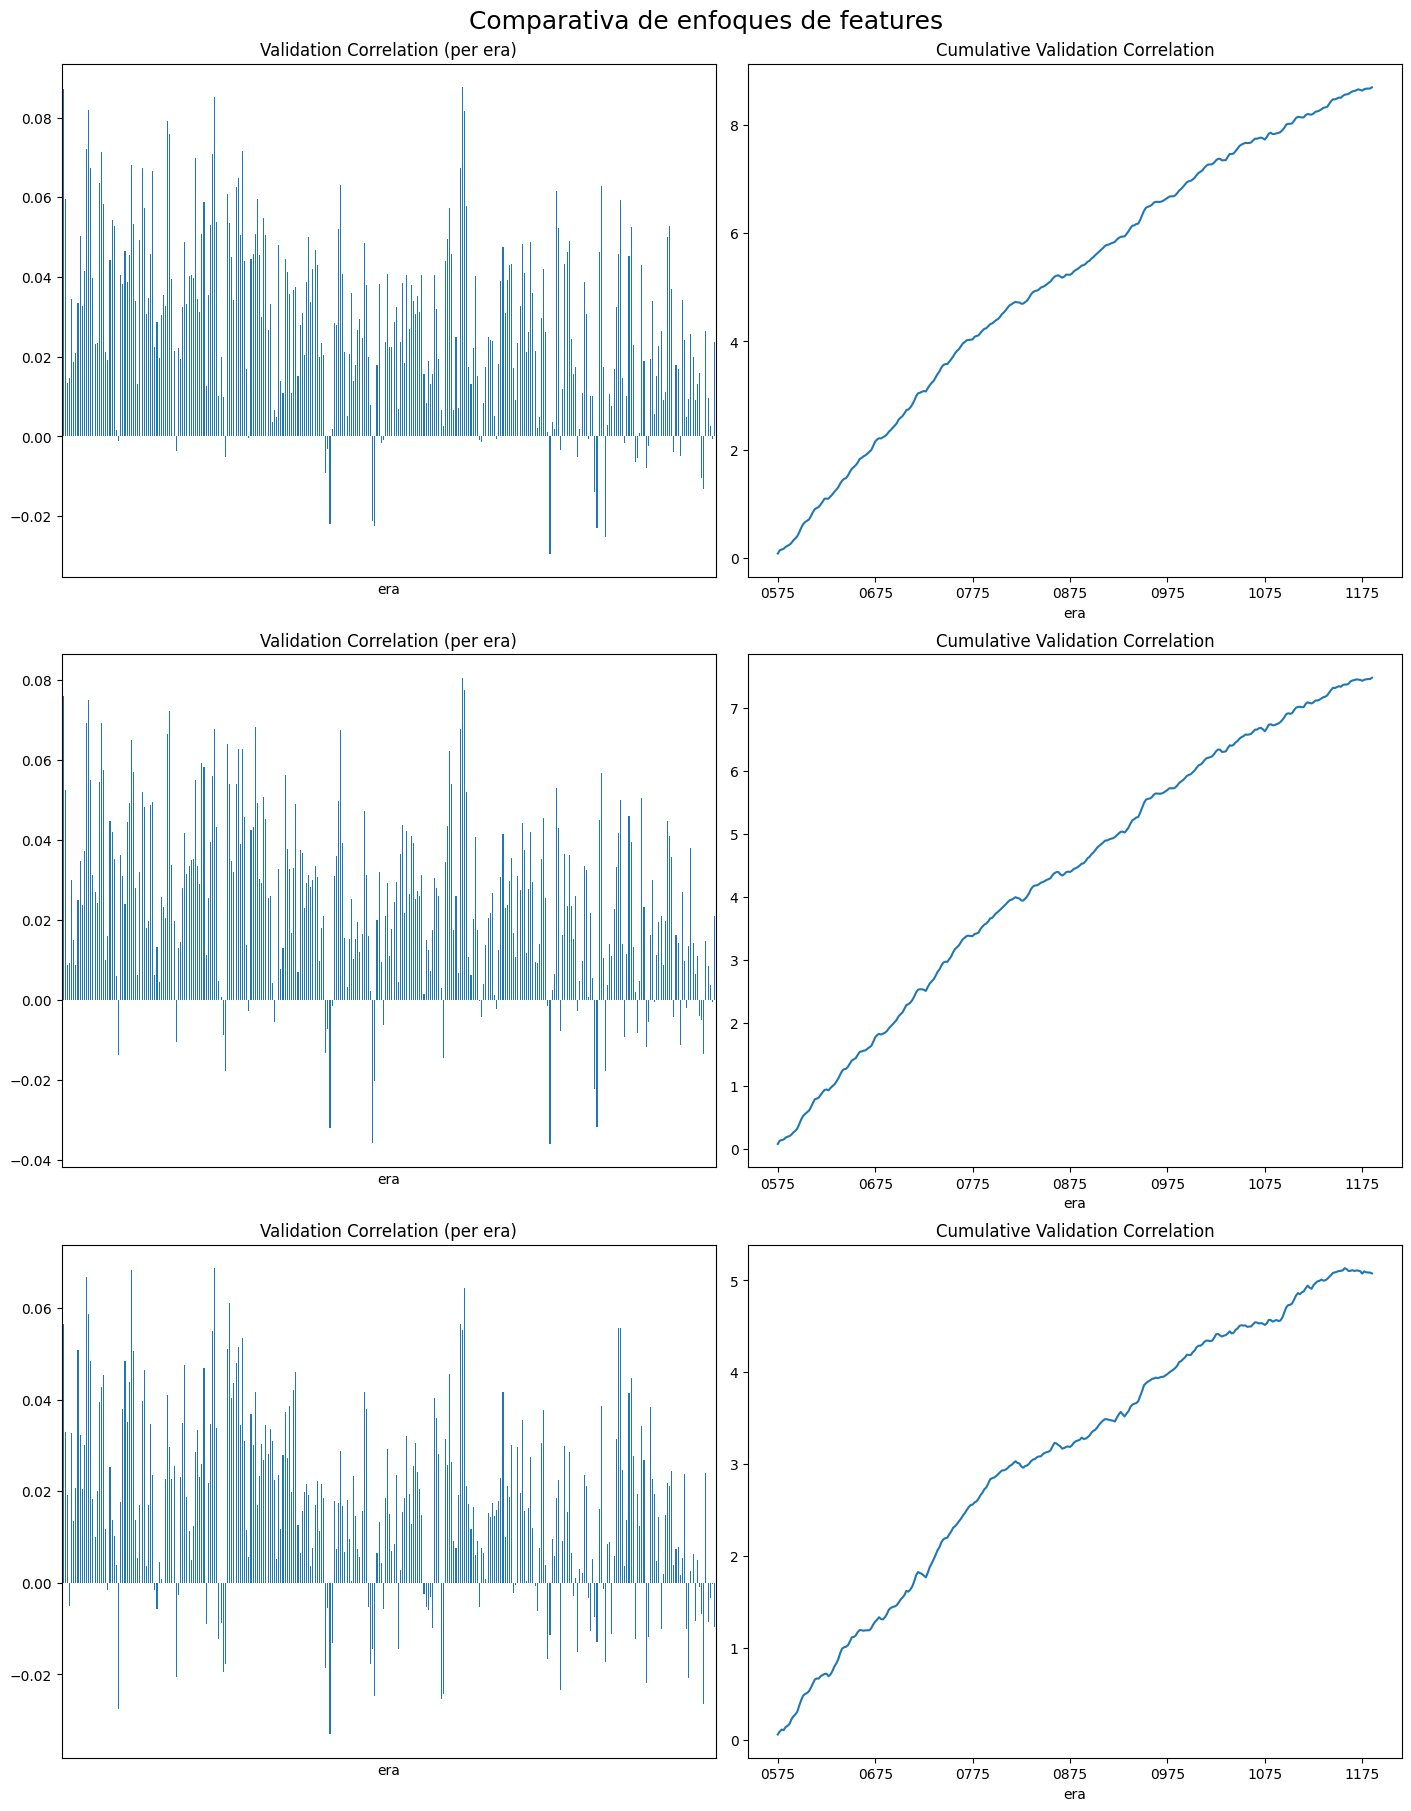

In [50]:
# Creo las figuras comparativas finales
fig, axes = plt.subplots(3, 2, figsize=(14, 18), constrained_layout=True)
fig.suptitle("Comparativa de enfoques de features", fontsize=18)

# Gráficas modelo inicial propuesto
ax = axes[0, 0]
per_era_corr_val_general.plot(kind="bar", title="Validation Correlation (per era)", xticks=[], ax=ax)
ax = axes[0, 1]
per_era_corr_val_general.cumsum().plot(kind="line", title="Cumulative Validation Correlation", ax=ax)

# Gráficas modelo con features eliminadas
ax = axes[1, 0]
per_era_corr_val_deleted_features.plot(kind="bar", title="Validation Correlation (per era)", xticks=[], ax=ax)
ax = axes[1, 1]
per_era_corr_val_deleted_features.cumsum().plot(kind="line", title="Cumulative Validation Correlation", ax=ax)

# Gráficas modelo con features PCA
ax = axes[2, 0]
per_era_corr_val_pca.plot(kind="bar", title="Validation Correlation (per era)", xticks=[], ax=ax)
ax = axes[2, 1]
per_era_corr_val_pca.cumsum().plot(kind="line", title="Cumulative Validation Correlation", ax=ax)


En las gráficas muestro la comparativa de los tres enfoques del modelo inicial en términos de la correlación por era y su acumulado a lo largo del tiempo.
Cada fila corresponde a un modelo distinto: el primero usa todas las características del dataset, el segundo aplica eliminación de características poco relevantes, y el tercero usa componentes principales (PCA).

Al observar los gráficos de la izquierda (Validation Correlation per era), noto que en todos los casos la correlación varía bastante entre eras, lo que refleja la naturaleza volátil de los datos financieros. Sin embargo, el modelo con todas las características (primera fila) muestra correlaciones más amplias, lo que indica mayor sensibilidad a los cambios del mercado, un poco más de ruido.
En cambio, el modelo con eliminación de características (segunda fila) mantiene menos picos negativos, lo que indica una mayor estabilidad entre eras.En cambio el modelo PCA (tercera fila) presenta correlaciones más pequeñas y acotadas.

En los gráficos de la derecha (Cumulative Validation Correlation), donde se observa la evolución acumulada de la correlación, se ve claramente que todos los modelos generan una tendencia creciente, lo que confirma que las predicciones tienen valor positivo acumulado a lo largo del tiempo.
No obstante, la pendiente del modelo completo es la más pronunciada, seguido del de eliminación de características, mientras que el PCA crece más lentamente. Esto coincide con los valores numéricos de las métricas: el modelo completo obtiene mayor correlación media, pero el de eliminación de características logra una curva más regular de crecimiento durante el tiempo, lo que sugiere que tiene una mayor robustez.

En conclusión, interpreto que los tres modelos logran capturar la señal de forma consistente, pero de forma distinta:
- El modelo completo tiene la mayor señal, pero también más volatilidad entre eras.
- El modelo con eliminación de características es el más equilibrado, manteniendo un crecimiento acumulado más estable.
- El modelo PCA ofrece una curva más suavizada del comportamiento, con menos riesgo de overfitting, aunque sacrificando parte del rendimiento.

# PRUEBA CON DISTINTOS MODELOS

In [51]:
# Guardar resultados para comparativas finales
results_new_models = {}

**Modelo XGBRegressor**


=== TEST METRICS (por eras) ===
                     0
mean          0.159226
std           0.042460
sharpe        3.749996
max_drawdown  0.000000

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.029054
std           0.021559
sharpe        1.347672
max_drawdown  0.036158


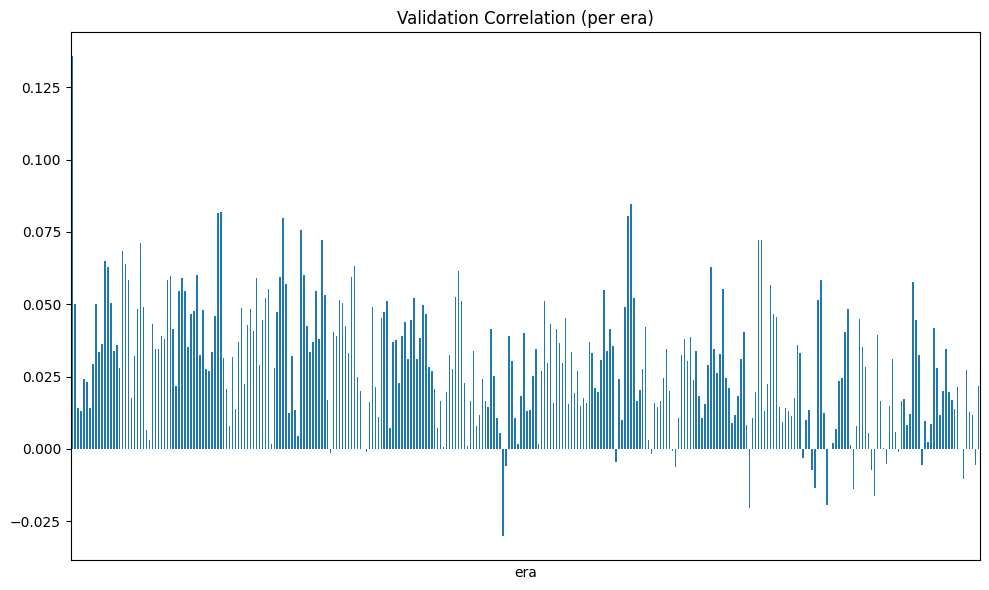

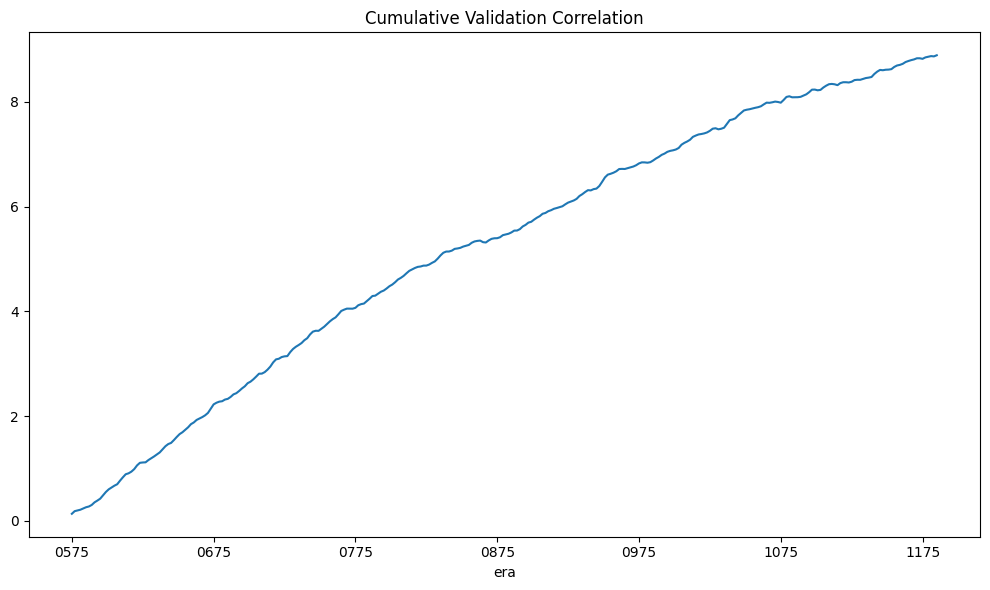


Preview VALID predictions:
                   era  prediction  target
id                                        
n000101811a8a843  0575    0.510783    0.75
n001e1318d5072ac  0575    0.514231    0.00
n002a9c5ab785cbb  0575    0.509373    0.50
n002ccf6d0e8c5ad  0575    0.527822    0.00
n0041544c345c91d  0575    0.509282    0.50


In [52]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

X = train_set[feature_set]
y = train_set["target"]
X_test = test_set[feature_set]
y_test = test_set["target"]

model = XGBRegressor(
    n_estimators=1500, learning_rate=0.02,
    max_depth=6, subsample=0.8, colsample_bytree=0.5,
    reg_lambda=2.0, random_state=42, tree_method="hist"
)
model.fit(X, y)

# Predicciones y métricas en TEST set
test = test_set.copy()
test["prediction"] = model.predict(X_test)
per_era_corr_test = test.groupby("era").apply(lambda df: practica_corr(df["prediction"], df["target"]))
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)

results_new_models["xgb_test"] = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}

# Predicciones y métricas en Validation set
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::2])].copy()
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo: 4 eras después de la última era de train_set
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
# eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

validation["prediction"] = model.predict(validation[feature_set])

per_era_corr_val = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val.mean()
corr_std_val = per_era_corr_val.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)

results_new_models["xgb_validation"] = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Gráficas VALID
plt.figure(figsize=(10, 6))
per_era_corr_val.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Preview
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "target"]].head())


**Modelo CatBoostRegressor**


=== TEST METRICS (por eras) ===
                     0
mean          0.083578
std           0.039822
sharpe        2.098806
max_drawdown  0.024641

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.026489
std           0.022233
sharpe        1.191440
max_drawdown  0.053288


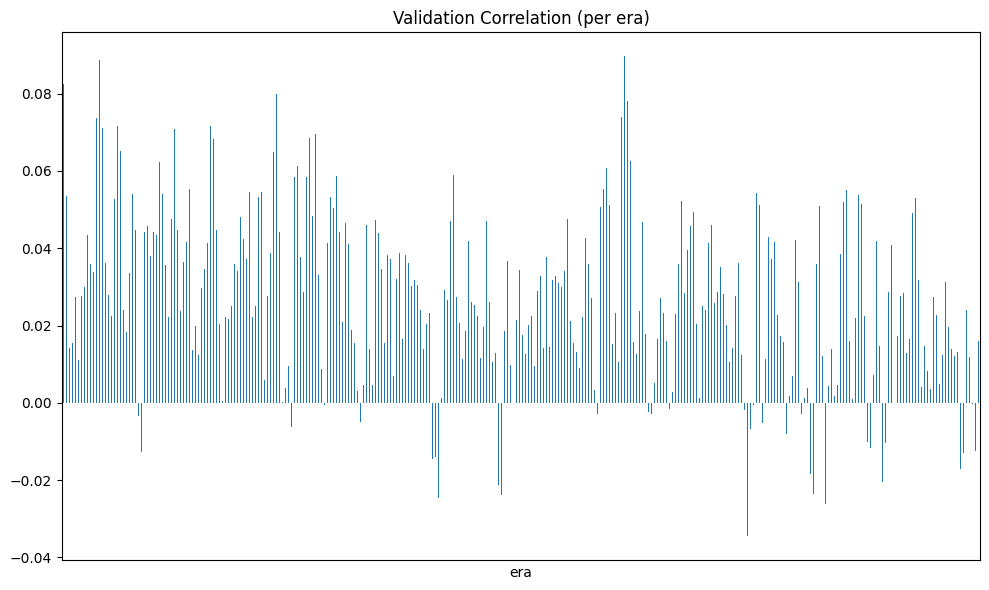

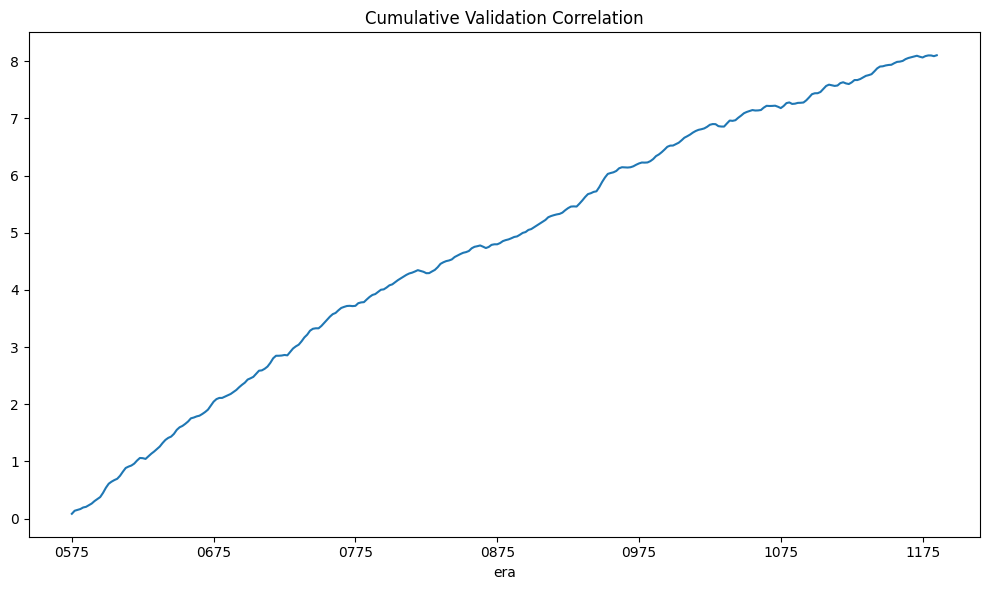


Preview VALID predictions:
                   era  prediction  target
id                                        
n000101811a8a843  0575    0.497035    0.75
n001e1318d5072ac  0575    0.508245    0.00
n002a9c5ab785cbb  0575    0.499917    0.50
n002ccf6d0e8c5ad  0575    0.514824    0.00
n0041544c345c91d  0575    0.510019    0.50


In [53]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

X = train_set[feature_set]
y = train_set["target"]
X_test = test_set[feature_set]
y_test = test_set["target"]

model = CatBoostRegressor(
    iterations=2000, learning_rate=0.01,
    depth=6, l2_leaf_reg=3.0,
    random_seed=42, verbose=0
)
model.fit(X, y)

# Predicciones y métricas en TEST set
test = test_set.copy()
test["prediction"] = model.predict(X_test)
per_era_corr_test = test.groupby("era").apply(lambda df: practica_corr(df["prediction"], df["target"]))
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)

results_new_models["catboost_test"] = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}

# Predicciones y métricas en Validation set
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::2])].copy()
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo: 4 eras después de la última era de train_set
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
# eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

validation["prediction"] = model.predict(validation[feature_set])

per_era_corr_val = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val.mean()
corr_std_val = per_era_corr_val.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)

results_new_models["catboost_validation"] = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Gráficas VALID
plt.figure(figsize=(10, 6))
per_era_corr_val.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Preview
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "target"]].head())


**Modelo RandomForest**


=== TEST METRICS (por eras) ===
                     0
mean          0.086716
std           0.041561
sharpe        2.086467
max_drawdown  0.040855

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.022560
std           0.022109
sharpe        1.020374
max_drawdown  0.079809


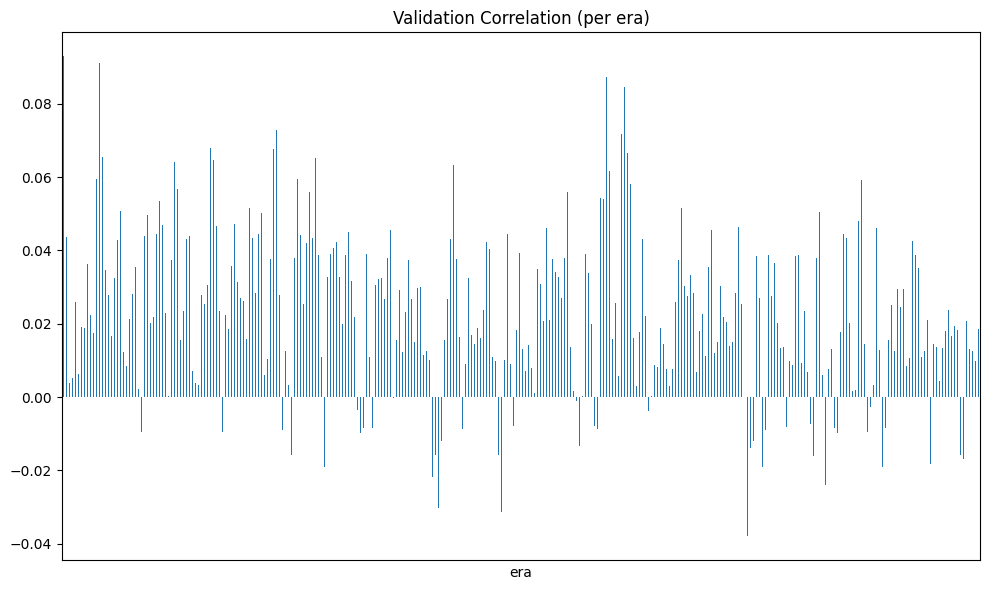

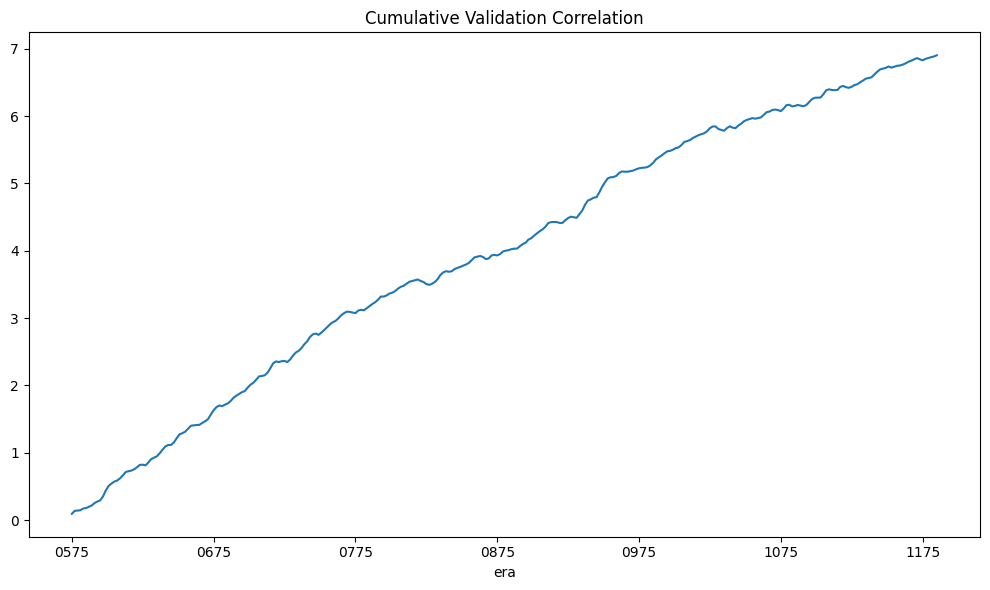


Preview VALID predictions:
                   era  prediction  target
id                                        
n000101811a8a843  0575    0.497441    0.75
n001e1318d5072ac  0575    0.504499    0.00
n002a9c5ab785cbb  0575    0.500352    0.50
n002ccf6d0e8c5ad  0575    0.506026    0.00
n0041544c345c91d  0575    0.502531    0.50


In [54]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

X = train_set[feature_set]
y = train_set["target"]
X_test = test_set[feature_set]
y_test = test_set["target"]

model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    verbose=0
)
model.fit(X, y)

# Predicciones y métricas en TEST set
test = test_set.copy()
test["prediction"] = model.predict(X_test)
per_era_corr_test = test.groupby("era").apply(lambda df: practica_corr(df["prediction"], df["target"]))
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)

results_new_models["randomforest_test"] = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}

# Predicciones y métricas en Validation set
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::2])].copy()
# validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo: 4 eras después de la última era de train_set
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
# eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

validation["prediction"] = model.predict(validation[feature_set])

per_era_corr_val = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val.mean()
corr_std_val = per_era_corr_val.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)

results_new_models["randomforest_validation"] = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Gráficas VALID
plt.figure(figsize=(10, 6))
per_era_corr_val.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Preview
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "target"]].head())


#### **Explicación resultados distintos modelos**

En esta tarea he implementado tres modelos distintos (XGBRegressor, CatBoostRegressor, RandomForestRegressor) para optimizar el rendimiento y adquirir uno mejor que el inicial propuesto de LGB. Todos son regressor ya que nuestro fin es predecir un valor numérico continuo, no una clasificación de los valores entrantes en categorias específicas.

He elegido modelos basados en árboles de decisión como XGBRegressor, CatBoostRegressor y RandomForestRegressor porque se adaptan mucho mejor al problema que se nos planteó respecto a otros métodos como la regresión lineal, logística o los SVM. Estos modelos son capaces de capturar relaciones no lineales y complejas entre las variables, algo que los modelos lineales no pueden hacer sin un fuerte pre-procesamiento. Además, no requieren escalado de datos ni suposiciones sobre la distribución, manejan bien outliers y grandes volúmenes de variables. Frente a los SVM o lineales, los modelos de árboles ofrecen una mayor estabilidad temporal y robustez, lo que los hacía la mejor opción para resolver la tarea puesto que además ya se daban los datos sin necesidad de hacer pre-procesamiento ni feature engineering.

*XGBRegressor:*

He utilizado XGBRegressor porque es un modelo de gradient boosting muy eficiente que construye árboles de forma secuencial, donde cada nuevo árbol corrige los errores del anterior. Esto permite al modelo capturar relaciones no lineales y complejas con precisión. Además, incluye regularización L1 y L2 para controlar el overfitting y ofrece un control sobre parámetros como la profundidad o la tasa de aprendizaje. Lo elegí porque es un estándar sólido en datos tabulares y me permite comparar el rendimiento de un boosting clásico frente a otros.

*CatBoostRegressor:*

Decidí emplear además CatBoostRegressor porque es una evolución moderna del gradient boosting que mejora la estabilidad y reduce el overfitting gracias a su método de ordered boosting. A diferencia de otros modelos, maneja automáticamente las variables categóricas (aunque no tenemos en nuestro dataset) y minimiza el target leakage, ofreciendo resultados consistentes sin necesidad de gran ajuste de hiperparámetros. Lo elegí por su robustez, su capacidad de generalización y su buen equilibrio entre rendimiento y facilidad de implementar.

*RandomForestRegressor:*

Incorporé también RandomForestRegressor como punto de comparación por ser visto en clase, ya que utiliza un enfoque de bagging, entrenando múltiples árboles en paralelo sobre subconjuntos aleatorios de los datos y promediando sus predicciones. Este modelo es muy estable y resistente al ruido, aunque no capta tan bien las interacciones complejas como los métodos con boosting. Lo elegí para tener una base sólida con la que contrastar los resultados y evaluar hasta qué punto las mejoras de los modelos de boosting se deben a su estructura secuencial y capacidad de ajuste.

**Comparación de resultados de los modelos en test**

En mis resultados de test, el XGBRegressor fue el modelo con mejor rendimiento, siendo el que alcanzó un Sharpe ratio y una correlación media más alta, lo que indica una señal más fuerte y estable. Esto se debe a que XGBoost optimiza los errores de forma secuencial mediante gradient boosting, aprovechando la regularización sin sobreajustar.

El CatBoostRegressor obtuvo un Sharpe elevado, con una señal algo más débil pero más controlada. Su rendimiento es consistente con su diseño orientado a la estabilidad: utiliza ordered boosting para evitar fugas de información, lo que me da robustez al modelo pero puede limitar la fuerza de la señal en comparación con XGBoost.

Por último, el RandomForestRegressor logró un Sharpe y una correlación media similar al CatBoostRegressor, mostrando buena estabilidad aunque menor potencia predictiva. Esto es coherente debido a su uso de bagging, que reduce la varianza promediando muchos árboles, pero sin la capacidad de corrección de errores que caracteriza a los modelos de boosting.

En los resultados de abajo confirman que XGBoost ofrece la señal más fuerte y eficiente, mientras que CatBoost y Random Forest destacan por su robustez y menor riesgo de sobreajuste, actuando como modelos más estables pero algo menos agresivos.

In [55]:
# Comparativa resultados Test nuevos modelos
results_new_models_test_df = pd.DataFrame({k: v for k, v in results_new_models.items() if "test" in k}).T
results_new_models_test_df

,mean,std,sharpe,max_drawdown
xgb_test,0.159226,0.042460,3.749996,0.000000
catboost_test,0.083578,0.039822,2.098806,0.024641
randomforest_test,0.086716,0.041561,2.086467,0.040855


**Comparación de resultados de los modelos en validation**

En el conjunto de validación, el XGBRegressor volvió a destacar con un Sharpe ratio y una correlación media más altas, lo que demuestra que mantiene una buena capacidad predictiva fuera de muestra con datos nuevos. Aunque su rendimiento baja respecto al test, sigue mostrando una señal sólida y una buena estabilidad temporal.

El CatBoostRegressor obtuvo un Sharpe y una correlación media ligeramente inferior. Esto confirma su comportamiento más conservador, ofreciendo resultados estables, pero su mecanismo de ordered boosting tiende a priorizar la generalización frente a la agresividad del ajuste, lo que reduce algo la fuerza de la predicción.

Por último, el RandomForestRegressor alcanzó un Sharpe ratio y correlación media más baja, junto con el mayor max drawdown. Este resultado refleja que, aunque el Random Forest es robusto al ruido, su enfoque basado en bagging y el promedio de árboles limita su capacidad para capturar patrones temporales complejos, mostrando menor rendimiento y estabilidad en validación.

En conclusión, los resultados de abajo confirman que XGBoost generaliza mejor, CatBoost ofrece buena estabilidad, y Random Forest, aunque consistente, pierde fuerza predictiva fuera de muestra.

In [59]:
# Comparativa resultados Validación nuevos modelos
results_new_models_validation_df = pd.DataFrame({k: v for k, v in results_new_models.items() if "validation" in k}).T
results_new_models_validation_df

,mean,std,sharpe,max_drawdown
xgb_validation,0.029054,0.021559,1.347672,0.036158
catboost_validation,0.026489,0.022233,1.191440,0.053288
randomforest_validation,0.022560,0.022109,1.020374,0.079809


### 4. Improvement & Investigation

In [60]:
# Guardar resultados para comparativas finales
xgbResults_summary = {}

#### 4.1 Feature Neutralization

*Feature Neutralization* es una técnica que utilizamos para eliminar o reducir la dependencia directa que hay entre las predicciones del modelo y las features.

Se utiliza porque algunas features pueden:
- Estar muy correlacionadas con el target solo en ciertos periodos de eras (overfitting temporal).
- Pueden reflejar patrones de relaciones que existen solo por casualidad.
- Pueden ser reutilizadas de otros modelos y reducir la diversificación.

Al hacer el *feature neutralization* a las predicciones respecto a las features, evitamos que el modelo dependa de ellas, lo que genera señales más robustas y generalizadas.

Para aplicarlo necesitamos hacer la correlación por eras y después la neutralización de las predicciones; de modo que suele ser más estable en el tiempo y menos dependiente de factores específicos.

$$
p' = p - F (F^T F)^{-1} F^T p
$$

Ahora lo aplico al modelo más óptimo visto anteriormente.

In [61]:
# Función que aplica Feature Neutralization
def feature_neutralization(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    proportion: float = 1.0
) -> pd.DataFrame:
    X = df[feature_cols].values
    y = df[target_col].values.reshape(-1, 1)
    model = LinearRegression(fit_intercept=False)
    model.fit(X, y)
    y_pred = model.predict(X)
    df[target_col + "_neutralized"] = y - proportion * y_pred
    return df



=== TEST METRICS (por eras) ===
                     0
mean          0.159226
std           0.042460
sharpe        3.749996
max_drawdown  0.000000

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.028502
std           0.020406
sharpe        1.396774
max_drawdown  0.020263

=== VALIDATION METRICS (neutralized) ===
                     0
mean          0.023502
std           0.019183
sharpe        1.225184
max_drawdown  0.032855


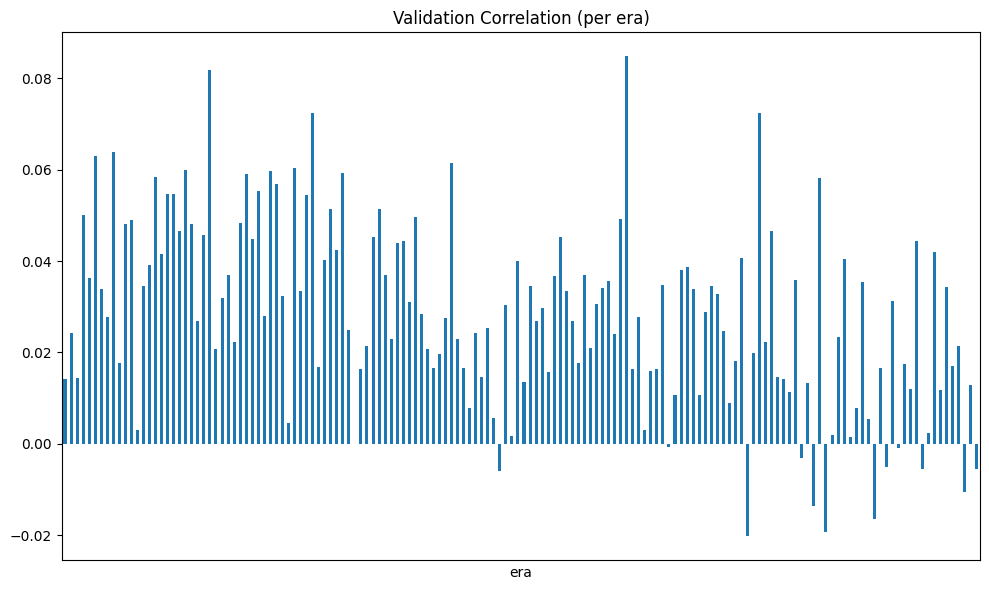

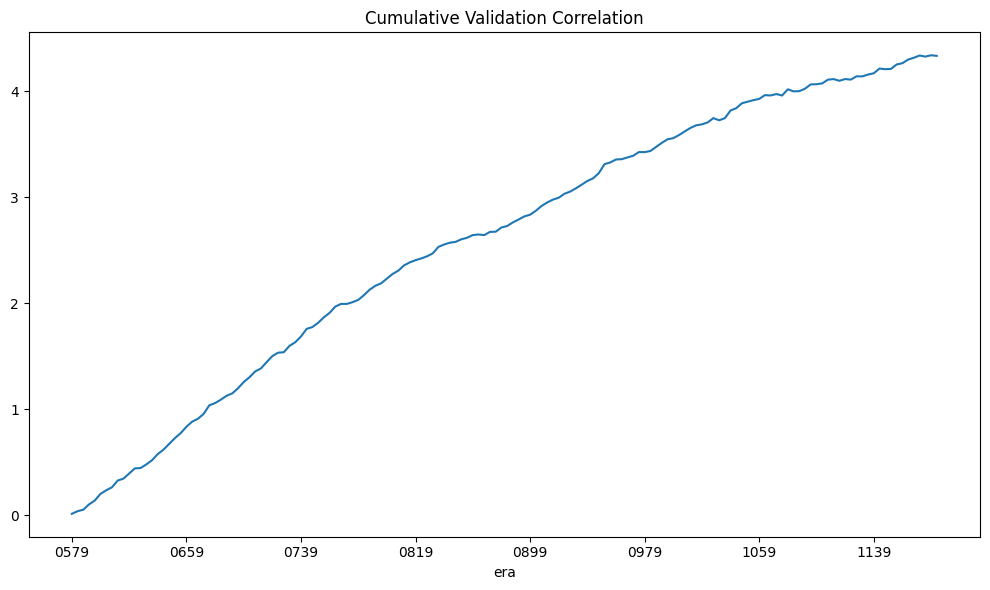

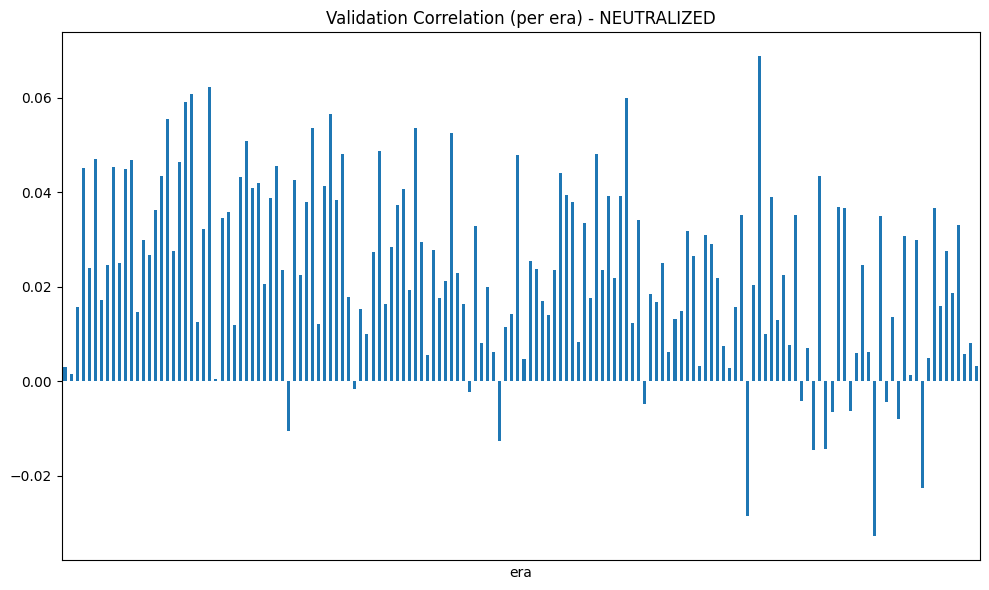

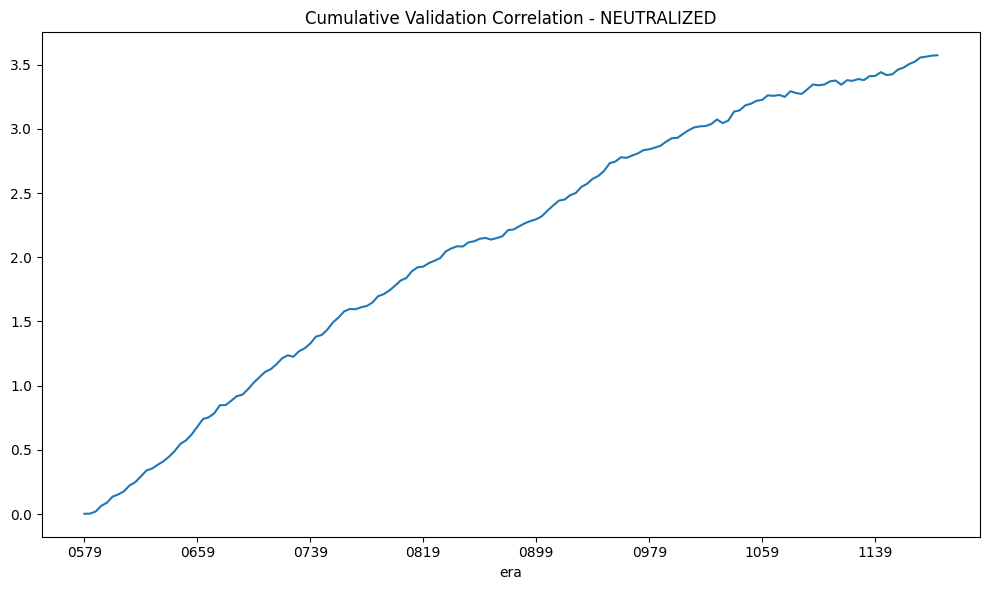


Preview VALID predictions:
                   era  prediction  prediction_neutralized  target
id                                                                
n000c290e4364875  0579    0.486130                0.250201    0.50
n002a15bc5575bbb  0579    0.512846                0.245304    0.25
n00309caaa0f955e  0579    0.519237                0.267936    0.75
n0039cbdcf835708  0579    0.499481                0.261465    0.50
n004143458984f89  0579    0.503206                0.251408    0.50


In [62]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Entrenamiento del modelo XGBRegressor
X = train_set[feature_set]
y = train_set["target"]
X_test = test_set[feature_set]
y_test = test_set["target"]

model = XGBRegressor(
    n_estimators=1500, learning_rate=0.02,
    max_depth=6, subsample=0.8, colsample_bytree=0.5,
    reg_lambda=2.0, random_state=42, tree_method="hist"
)

model.fit(X, y)

# Métricas en TEST
test = test_set.copy()
test["prediction"] = model.predict(X_test)

per_era_corr_test = test.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)

xgbResults_summary["Test"] = {
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}

# Métricas en VALIDATION
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo de 4 eras posteriores a la última de train
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

validation["prediction"] = model.predict(validation[feature_set])

per_era_corr_val = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val.mean()
corr_std_val = per_era_corr_val.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)

xgbResults_summary["Validation"] = {
    "mean": corr_mean_val,
    "std": corr_std_val,
    "sharpe": corr_sharpe_val,
    "max_drawdown": max_drawdown_val
}

# Feature Neutralization aplicada a VALIDATION
validation = feature_neutralization(
    df=validation,
    feature_cols=feature_set,
    target_col="prediction",
    proportion=0.5
)

per_era_corr_val_neu = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction_neutralized"], df["target"])
)

corr_mean_val_neu = per_era_corr_val_neu.mean()
corr_std_val_neu = per_era_corr_val_neu.std(ddof=0)
corr_sharpe_val_neu = corr_mean_val_neu / corr_std_val_neu if corr_std_val_neu > 0 else np.nan
cum_val_neu = per_era_corr_val_neu.cumsum()
max_drawdown_val_neu = (cum_val_neu.expanding(min_periods=1).max() - cum_val_neu).max()

print("\n=== VALIDATION METRICS (neutralized) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val_neu],
    "std": [corr_std_val_neu],
    "sharpe": [corr_sharpe_val_neu],
    "max_drawdown": [max_drawdown_val_neu]
}).T)

xgbResults_summary["Feature Neutralization"] = {
    "mean": corr_mean_val_neu,
    "std": corr_std_val_neu,
    "sharpe": corr_sharpe_val_neu,
    "max_drawdown": max_drawdown_val_neu
}

# Gráficas VALIDATION
plt.figure(figsize=(10, 6))
per_era_corr_val.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Gráficas Neutralized
plt.figure(figsize=(10, 6))
per_era_corr_val_neu.plot(kind="bar", title="Validation Correlation (per era) - NEUTRALIZED", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val_neu.cumsum().plot(kind="line", title="Cumulative Validation Correlation - NEUTRALIZED")
plt.tight_layout()
plt.show()

# Preview
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "prediction_neutralized", "target"]].head())


#### 4.2 Ridge Regression

*Ridge Regression* es una forma de regresión lineal regularizada que añade una penalización a los coeficientes del modelo dependiendo de su tamaño. El objetivo es evitar es overfitting y gestionar la colinealidad entre las variables.

Su función principal es suavizar el modelo, ya que en lugar de dejar que algunas features dominen con coeficientes grandes, los penaliza y distribuye más equilibradamente con *L2*. Hace que sea imprescindible cuando hay muchas variables correlacionadas.

$$
\text{MSE}_{\text{ridge}} = \|y - Xw\|^2 + \lambda \|w\|^2
$$

Ahora lo aplico también al modelo más óptimo visto anteriormente.

In [63]:
# Función que aplica Ridge Regression
def ridge_regression_features(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    alpha: float = 1.0
) -> pd.DataFrame:
    X = df[feature_cols].values
    y = df[target_col].values
    model = Ridge(alpha=alpha)
    model.fit(X, y)
    df[target_col + "_ridge_pred"] = model.predict(X)
    return df


=== TEST METRICS (por eras) ===
                     0
mean          0.159226
std           0.042460
sharpe        3.749996
max_drawdown  0.000000

=== VALIDATION METRICS (por eras) ===
                     0
mean          0.028502
std           0.020406
sharpe        1.396774
max_drawdown  0.020263

=== VALIDATION METRICS (ridge regression) ===
                     0
mean          0.015532
std           0.018537
sharpe        0.837904
max_drawdown  0.031479


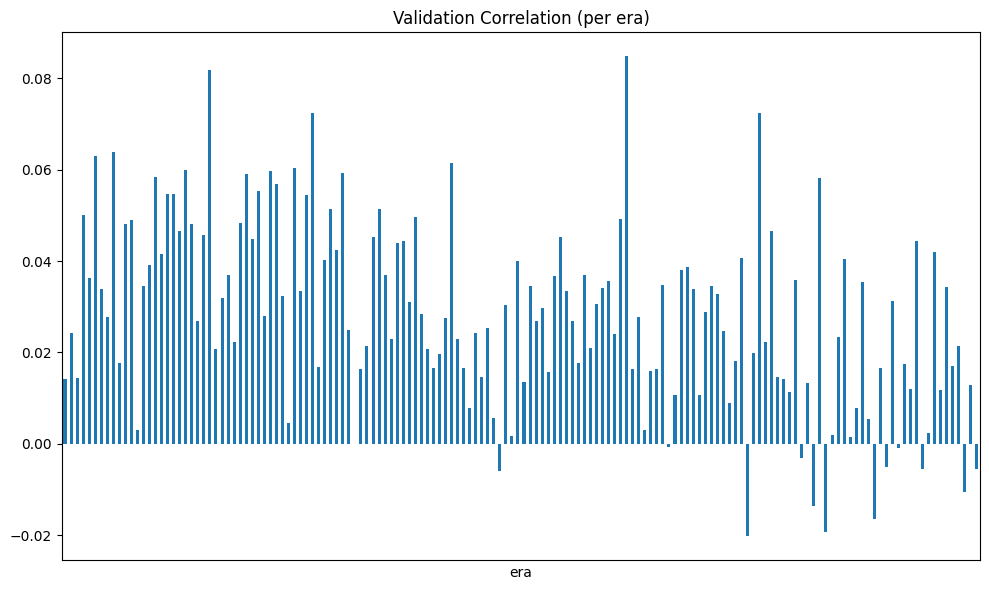

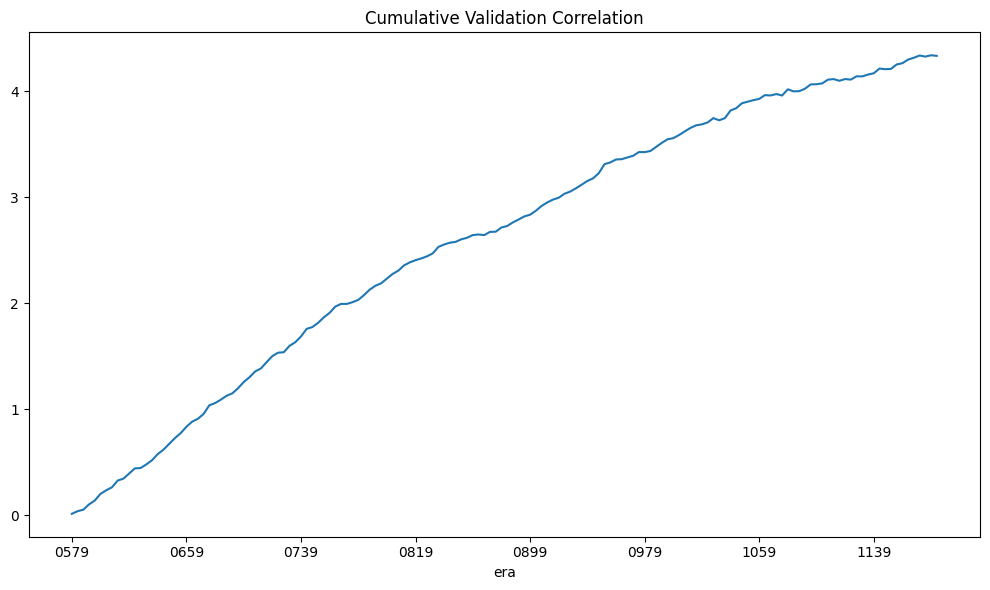

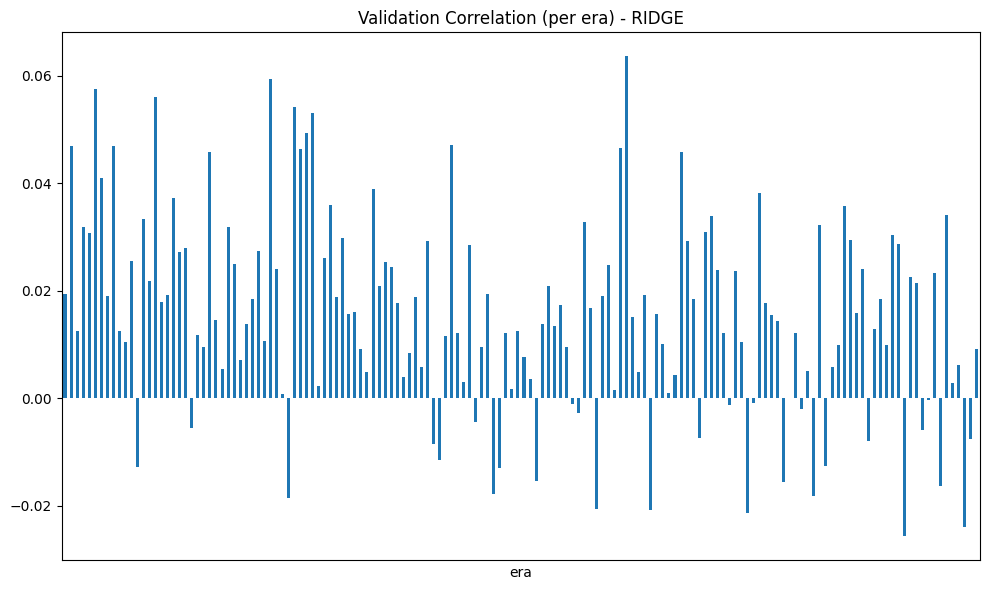

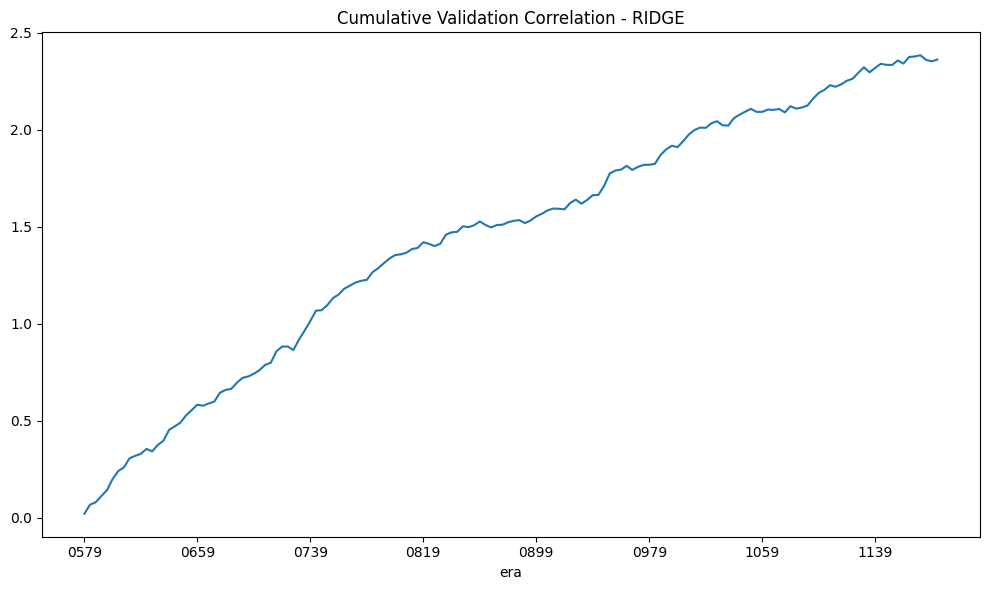


Preview VALID predictions:
                   era  prediction  prediction_ridge_pred  target
id                                                               
n000c290e4364875  0579    0.486130               0.494482    0.50
n002a15bc5575bbb  0579    0.512846               0.503171    0.25
n00309caaa0f955e  0579    0.519237               0.502709    0.75
n0039cbdcf835708  0579    0.499481               0.487233    0.50
n004143458984f89  0579    0.503206               0.501977    0.50


In [64]:
def practica_corr(preds: pd.Series, target: pd.Series) -> float:
    ranked = (preds.rank(method="average").values - 0.5) / preds.count()
    ranked = np.clip(ranked, 1e-6, 1 - 1e-6)
    gauss = stats.norm.ppf(ranked)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss) * np.abs(gauss) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Entrenamiento del modelo XGBRegressor
X = train_set[feature_set]
y = train_set["target"]
X_test = test_set[feature_set]
y_test = test_set["target"]

model = XGBRegressor(
    n_estimators=1500, learning_rate=0.02,
    max_depth=6, subsample=0.8, colsample_bytree=0.5,
    reg_lambda=2.0, random_state=42, tree_method="hist"
)

model.fit(X, y)

# Métricas en TEST
test = test_set.copy()
test["prediction"] = model.predict(X_test)

per_era_corr_test = test.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)
corr_mean = per_era_corr_test.mean()
corr_std = per_era_corr_test.std(ddof=0)
corr_sharpe = corr_mean / corr_std if corr_std > 0 else np.nan
cum = per_era_corr_test.cumsum()
max_drawdown = (cum.expanding(min_periods=1).max() - cum).max()

print("\n=== TEST METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean],
    "std": [corr_std],
    "sharpe": [corr_sharpe],
    "max_drawdown": [max_drawdown]
}).T)

# Métricas en VALIDATION
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"].copy()
del validation["data_type"]

# reducir cada 4 eras para acelerar
validation = validation[validation["era"].isin(validation["era"].unique()[::4])].copy()

# Embargo de 4 eras posteriores a la última de train
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(4) for i in range(1, 5)}
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

validation["prediction"] = model.predict(validation[feature_set])

per_era_corr_val = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction"], df["target"])
)

corr_mean_val = per_era_corr_val.mean()
corr_std_val = per_era_corr_val.std(ddof=0)
corr_sharpe_val = corr_mean_val / corr_std_val if corr_std_val > 0 else np.nan
cum_val = per_era_corr_val.cumsum()
max_drawdown_val = (cum_val.expanding(min_periods=1).max() - cum_val).max()

print("\n=== VALIDATION METRICS (por eras) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val],
    "std": [corr_std_val],
    "sharpe": [corr_sharpe_val],
    "max_drawdown": [max_drawdown_val]
}).T)

# Aplicar Ridge Regression sobre la predicción
validation = ridge_regression_features(
    df=validation,
    feature_cols=feature_set,
    target_col="prediction",
    alpha=10.0
)

per_era_corr_val_ridge = validation.groupby("era").apply(
    lambda df: practica_corr(df["prediction_ridge_pred"], df["target"])
)

corr_mean_val_ridge = per_era_corr_val_ridge.mean()
corr_std_val_ridge = per_era_corr_val_ridge.std(ddof=0)
corr_sharpe_val_ridge = corr_mean_val_ridge / corr_std_val_ridge if corr_std_val_ridge > 0 else np.nan
cum_val_ridge = per_era_corr_val_ridge.cumsum()
max_drawdown_val_ridge = (cum_val_ridge.expanding(min_periods=1).max() - cum_val_ridge).max()

print("\n=== VALIDATION METRICS (ridge regression) ===")
print(pd.DataFrame({
    "mean": [corr_mean_val_ridge],
    "std": [corr_std_val_ridge],
    "sharpe": [corr_sharpe_val_ridge],
    "max_drawdown": [max_drawdown_val_ridge]
}).T)

xgbResults_summary["Ridge Regression"] = {
    "mean": corr_mean_val_ridge,
    "std": corr_std_val_ridge,
    "sharpe": corr_sharpe_val_ridge,
    "max_drawdown": max_drawdown_val_ridge
}

# Gráficas VALIDATION
plt.figure(figsize=(10, 6))
per_era_corr_val.plot(kind="bar", title="Validation Correlation (per era)", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val.cumsum().plot(kind="line", title="Cumulative Validation Correlation")
plt.tight_layout()
plt.show()

# Gráficas Ridge Regression
plt.figure(figsize=(10, 6))
per_era_corr_val_ridge.plot(kind="bar", title="Validation Correlation (per era) - RIDGE", xticks=[])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
per_era_corr_val_ridge.cumsum().plot(kind="line", title="Cumulative Validation Correlation - RIDGE")
plt.tight_layout()
plt.show()

# Preview
print("\nPreview VALID predictions:")
print(validation[["era", "prediction", "prediction_ridge_pred", "target"]].head())


#### 4.3 Comparación del modelo inicial, feature neutralization & ridge regression

Tras aplicar Feature Neutralization y Ridge Regression, vemos en las métricas abajo una penalización respecto al modelo inicial. En el caso de la feature neutralization en validation, el Sharpe ratio y la correlación media bajaron ligeramente. Esto ha ocurrido porque este proceso elimina de las predicciones toda la parte que está explicada por las features. Al neutralizar quito información que el modelo había aprendido directamente de las variables, por lo que la fuerza de la señal se debilita. Sin embargo, esta reducción tiene como objetivo hacer que las predicciones sean más independientes y robustas, disminuyendo la posibilidad de que el modelo dependa de patrones temporales.

En el caso de la Ridge Regression, la media bajó y el Sharpe también. Esto se debe a que la regresión Ridge penaliza la magnitud de los coeficientes, suavizando las predicciones y reduciendo su varianza. Aunque esto mejora la estabilidad y controla el sobreajuste, también provoca una pérdida de intensidad en la señal, ya que las diferencias entre predicciones se hacen más pequeñas.

Tanto la feature neutralization como la ridge regression no suelen buscar como fín mejorar el rendimiento inmediato, sino reducir la dependencia del modelo respecto a las features originales y aumentar su capacidad de generalización en entornos reales. Por eso, aunque las métricas bajan, el modelo resultante es más estable, robusto y menos propenso a sobreajustar.

In [65]:
xgbResults_summary_df = pd.DataFrame(xgbResults_summary)
xgbResults_summary_df

,Test,Validation,Feature Neutralization,Ridge Regression
mean,0.159226,0.028502,0.023502,0.015532
std,0.042460,0.020406,0.019183,0.018537
sharpe,3.749996,1.396774,1.225184,0.837904
max_drawdown,0.000000,0.020263,0.032855,0.031479


### 5. Submission

#### 5.1 Validación del modelo con archivo live.parquet

In [66]:
live = pd.read_parquet(
    f"{DATA_VERSION}/live.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
live


,era,data_type,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
id,,,,,,,,,,,,,,,,,,,,,
n001b75325026337,X,live,NaN,0,0,4,4,0,2,4,...,4,4,0,0,0,0,4,0,1,1
n00239a19e9ab1d5,X,live,NaN,4,2,4,1,3,4,2,...,0,3,0,2,3,4,1,4,1,2
n002a614bb19c07d,X,live,NaN,2,3,0,0,4,0,4,...,0,4,3,2,4,4,2,4,3,4
n002e637a2c2f21d,X,live,NaN,2,1,1,4,2,0,4,...,2,3,2,4,4,4,2,1,0,0
n002f911e41c11e9,X,live,NaN,2,3,2,0,3,1,4,...,0,3,1,2,4,2,2,1,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc9c417524816e,X,live,NaN,4,1,0,2,3,0,0,...,3,3,1,4,2,3,4,2,3,3
nffd495695fd863c,X,live,NaN,0,0,4,3,4,3,0,...,2,0,4,2,3,1,4,3,1,2
nffe2098e2a8047c,X,live,NaN,1,1,2,2,2,4,2,...,0,2,2,1,1,3,1,2,2,2


In [ ]:
X = train_set[feature_set]
y = train_set["target"]
X_test = live[feature_set]

model_live = XGBRegressor(
    n_estimators=1500, learning_rate=0.02,
    max_depth=6, subsample=0.8, colsample_bytree=0.5,
    reg_lambda=2.0, random_state=42, tree_method="hist"
)
model_live.fit(X, y)

df_live = live.copy()
# df_live = df_live[df_live["data_type"] == "live"].copy()
# del df_live["data_type"]

# reducir cada 4 eras para acelerar
df_live = df_live[df_live["era"].isin(df_live["era"].unique()[::2])].copy()

# Embargo: 4 eras después de la última era de train_set
last_train_era = int(train_set["era"].astype(int).max())
eras_to_embargo = {str(last_train_era + i).zfill(2) for i in range(1, 5)}
df_live = df_live[~df_live["era"].isin(eras_to_embargo)].copy()

X_live = df_live[feature_set]
df_live["prediction"] = model_live.predict(X_test)
df_live.reset_index(inplace=True)
df_live.rename(columns={"index": "id"}, inplace=True)

df_live[["id", "prediction"]].head()


,id,prediction
0,n001b75325026337,0.492391
1,n00239a19e9ab1d5,0.515044
2,n002a614bb19c07d,0.508906
3,n002e637a2c2f21d,0.552473
4,n002f911e41c11e9,0.497922


#### 5.2 Generación del artefacto

He generado el artefacto del modelo con *cloudpickle*, esta libreria permite guardar objetos complejos de python en un archivo *.pkl*. De este modo se exporta y podemos volver a cargarlo con el modelo que se guardó dentro y así probarlo con nuevos datos. Otra libreria que realiza lo mismo es *keras* generando un archivo *.keras*, la diferencia es que *keras* es para uso exclusivo de redes neuronales y *cloudpickle* es más flexible para crear artefactos y puedes guardar dentro cualquier tipo de modelo o función de python.

In [69]:
# Exportar el modelo con cloudpickle
model_filename = "model_final_JoseSuarez.pkl"
with open(model_filename, "wb") as f:
    cloudpickle.dump(model_live, f)
    
print(f"\nModelo exportado a '{model_filename}' con cloudpickle.")


Modelo exportado a 'model_final_JoseSuarez.pkl' con cloudpickle.
